# 09A — การวิเคราะห์เหตุการณ์พายุรุนแรงและลูกเห็บแบบบูรณาการ
## Integrated Severe-Storm and Hail Event Analysis

**Track A — Applied Radar–GIS / Environmental Research**

กรณีศึกษา:

- Omkoi S-band weather radar
- Observed-hail event: 18 March 2023
- Event window: approximately 11:06–12:00 UTC
- Inputs: outputs from Notebooks 03, 07 and 08
- Optional contextual input: Notebook 05 event-centered QPE
- Environmental thermal input in Notebook 08: Dien Bien Phu remote observed sounding proxy

---

## จุดมุ่งหมายของบท

Notebook 02–08 วิเคราะห์ตัวแปรแต่ละกลุ่มแยกกัน

Notebook 09A จะรวมทั้งหมดเพื่อสร้าง **event-scale physical narrative**:

```text
Horizontal storm structure
        +
Vertical storm structure
        +
Severe-core metrics
        +
Hail-specific retrieval
        +
Temporal evolution
        ↓
Integrated event interpretation
```

ตัวแปรหลัก:

```text
Maximum ZH
Height of maximum ZH
ET40
ET50
VIL
VILD
40/50-dBZ echo volume
Severe-core area
SHI
MESH
POSH
```

> เป้าหมายไม่ใช่สร้าง “severity score” ใหม่  
> แต่คือดูว่าแต่ละ diagnostic บอกอะไร และ peak พร้อมกันหรือไม่

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 09A ผู้เรียนควรสามารถ:

1. reuse outputs จาก notebooks ก่อนหน้าโดยไม่คำนวณซ้ำ
2. ตรวจ provenance และ readiness ก่อนรวมข้อมูล
3. harmonize radar timestamps
4. สร้าง integrated lifecycle table
5. เปรียบเทียบ horizontal, vertical และ hail metrics
6. ระบุ peak time ของแต่ละ metric
7. คำนวณ peak-time lag อย่างเป็น descriptive analysis
8. normalize metrics เพื่อเปรียบเทียบ temporal evolution
9. ใช้ Spearman correlation แบบ exploratory สำหรับ sample ขนาดเล็ก
10. แยก association ออกจาก causation
11. สร้าง publication-quality lifecycle figures
12. สร้าง peak spatial-product inventory
13. plot severe-storm and hail products ด้วย spatial extent ที่สอดคล้องกัน
14. เชื่อม event-level observed hail กับ radar-derived diagnostics อย่างระมัดระวัง
15. เขียน event-scale Results paragraph จากข้อมูลจริง
16. สร้าง output package สำหรับ Notebook 10A GIS exposure analysis

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**RESEARCH NOTE** — ประเด็นสำหรับ manuscript

# 1. Integrated-event framework

แนวคิดหลัก:

```text
Radar reflectivity intensification
        ↓
Vertical extension of strong echo
        ↓
Increase in liquid/ice loading proxies
        ↓
Hail-specific radar retrieval
        ↓
Spatial and temporal synthesis
```

แต่ลำดับข้างต้นเป็น **conceptual framework** ไม่ใช่ข้อสรุปว่าเหตุการณ์จริงต้องเกิดตามลำดับนี้

Notebook จะให้ข้อมูลตอบคำถาม:

- Max ZH peak เวลาใด?
- ET50 peak เวลาใด?
- VIL peak เวลาใด?
- MESH peak เวลาใด?
- metrics เหล่านี้ peak ต่างกันกี่นาที?
- spatial maxima อยู่ใน storm core เดียวกันหรือไม่?

# 2. ข้อควรระวัง

### Observed hail event

หมายถึงมีหลักฐาน event-level ว่ามีลูกเห็บในเหตุการณ์

ไม่ได้หมายความว่า:

```text
ทุก radar pixel = verified hail
```

### MESH

คือ radar-derived hail-size estimate

ไม่ได้หมายความว่า:

```text
MESH 40 mm = วัดลูกเห็บจริง 40 mm
```

### Correlation

หากมีเพียง 10 radar volumes:

```text
correlation = exploratory
```

ไม่ควรตีความเป็น population-level statistical relationship

### Peak lag

เช่น MESH peak ก่อน VIL 6 นาที เป็น descriptive timing difference

ไม่ใช่ causal lead–lag proof

# 3. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "numpy>=1.26",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "scipy>=1.12",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing/checking Notebook 09A packages ...")
subprocess.check_call(cmd)
print("Package installation complete.")

Installing/checking Notebook 09A packages ...
Package installation complete.


# 4. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "google.colab not found — using current directory:"
    )
    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 5. นำเข้าไลบรารี

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import json
import sys
import math
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import rasterio

from scipy.stats import spearmanr

from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)

,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,rasterio,1.5.1


In [4]:
# CELL 4 — Publication plotting standard

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )

# 6. อ่าน configuration และตรวจ readiness

Notebook 09A **ไม่คำนวณ severe/hail metrics ซ้ำ**

แต่ใช้ outputs จาก:

```text
03 → Cartesian grid / spatial framework
07 → severe-core lifecycle
08 → SHI / MESH / POSH lifecycle and thermal provenance
```

Notebook 05 เป็น optional context เท่านั้น

In [5]:
# CELL 5 — Load course configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "course_config.json not found — run Notebook 01 first."
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Notebook 09A expects the observed-hail event."
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

Active event: 20230318_observed_hail_1106_1200


In [6]:
# CELL 6 — Paths

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "09A"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

READINESS_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_readiness_check.csv"
)

READINESS_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

LIFECYCLE_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_severe_storm_lifecycle_metrics.csv"
)

MESH_LIFECYCLE_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_MESH_lifecycle.csv"
)

THERMAL_PROVENANCE_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_thermal_input_provenance.csv"
)

PROCESSING_METADATA_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_processing_metadata.csv"
)

HAIL_GEOTIFF_MANIFEST_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_hail_GeoTIFF_manifest.csv"
)

QPE_READINESS_05_CSV = (
    OUTPUT_CSV_DIR
    / "05_readiness_check.csv"
)

In [7]:
# CELL 7 — Required-file checks

REQUIRED_FILES = [
    READINESS_03_CSV,
    READINESS_07_CSV,
    READINESS_08_CSV,
    GRID_CONFIG_03_CSV,
    LIFECYCLE_07_CSV,
    MESH_LIFECYCLE_08_CSV,
    THERMAL_PROVENANCE_08_CSV,
    PROCESSING_METADATA_08_CSV,
]

missing_required = [
    str(
        path
    )
    for path in (
        REQUIRED_FILES
    )
    if not Path(
        path
    ).exists()
]

if missing_required:
    raise FileNotFoundError(
        "Missing required outputs:\n"
        + "\n".join(
            missing_required
        )
    )

print(
    "Required Notebook 03/07/08 outputs found."
)

Required Notebook 03/07/08 outputs found.


In [8]:
# CELL 8 — Readiness validation

readiness_03 = pd.read_csv(
    READINESS_03_CSV
)

readiness_07 = pd.read_csv(
    READINESS_07_CSV
)

readiness_08 = pd.read_csv(
    READINESS_08_CSV
)


def readiness_passed(
    table,
):
    if "status" not in (
        table.columns
    ):
        return False

    return bool(
        (
            table[
                "status"
            ]
            == "PASS"
        ).all()
    )


READINESS_SUMMARY = pd.DataFrame([
    {
        "notebook": "03",
        "ready": (
            readiness_passed(
                readiness_03
            )
        ),
    },
    {
        "notebook": "07",
        "ready": (
            readiness_passed(
                readiness_07
            )
        ),
    },
    {
        "notebook": "08",
        "ready": (
            readiness_passed(
                readiness_08
            )
        ),
    },
])

display(
    READINESS_SUMMARY
)

if not (
    READINESS_SUMMARY[
        "ready"
    ]
).all():
    raise RuntimeError(
        "Notebook 03, 07 or 08 readiness is not fully PASS."
    )

,notebook,ready
0,03,True
1,07,True
2,08,True


# 7. Thermal provenance ต้องเดินทางมาพร้อม MESH

Notebook 09A ไม่ต้อง derive thermal levels ใหม่

แต่ต้องรู้ว่า MESH ที่ใช้มาจาก environment แบบใด

ในกรณีนี้ default จาก Notebook 08 คือ:

```text
remote observed sounding proxy
Dien Bien Phu
WMO 48811
```

ดังนั้นทุก integrated interpretation ต้องรักษา provenance นี้ไว้

In [9]:
# CELL 9 — Load thermal provenance and 08 metadata

THERMAL_PROVENANCE_08 = pd.read_csv(
    THERMAL_PROVENANCE_08_CSV
)

PROCESSING_METADATA_08 = pd.read_csv(
    PROCESSING_METADATA_08_CSV
)

thermal_lookup = dict(
    zip(
        THERMAL_PROVENANCE_08[
            "parameter"
        ],
        THERMAL_PROVENANCE_08[
            "value"
        ],
    )
)

metadata_08_lookup = dict(
    zip(
        PROCESSING_METADATA_08[
            "parameter"
        ],
        PROCESSING_METADATA_08[
            "value"
        ],
    )
)

THERMAL_INPUT_MODE = str(
    metadata_08_lookup.get(
        "thermal_input_mode",
        "unknown",
    )
)

THERMAL_SOURCE_LABEL = str(
    metadata_08_lookup.get(
        "thermal_source_label",
        "unknown",
    )
)

print(
    "Thermal input mode:",
    THERMAL_INPUT_MODE,
)

print(
    "Thermal source:",
    THERMAL_SOURCE_LABEL,
)

display(
    THERMAL_PROVENANCE_08
)

Thermal input mode: PROXY_SOUNDING
Thermal source: PROXY_OBSERVED_WMO48811


,parameter,value
0,thermal_input_mode,PROXY_SOUNDING
1,thermal_source_type,remote observed sounding proxy
2,source_station,Dien Bien Phu
3,source_WMO,48811
4,source_latitude_deg,21.37
5,source_longitude_deg,103.0
6,source_profile_time_UTC,2023-03-17 23:45:00+00:00
7,source_nominal_time_UTC,2023-03-18 00:00:00+00:00
8,peak_radar_time_UTC,2023-03-18 11:12:02+00:00
9,distance_source_to_radar_km,621.7763649553929


In [10]:
# CELL 10 — Load Notebook 03 grid configuration

GRID_CONFIG_03 = pd.read_csv(
    GRID_CONFIG_03_CSV
)

GRID_CONFIG_LOOKUP = dict(
    zip(
        GRID_CONFIG_03[
            "parameter"
        ],
        GRID_CONFIG_03[
            "value"
        ],
    )
)

RADAR_LAT = float(
    GRID_CONFIG_LOOKUP[
        "radar_latitude_deg"
    ]
)

RADAR_LON = float(
    GRID_CONFIG_LOOKUP[
        "radar_longitude_deg"
    ]
)

RADAR_ALTITUDE_M_MSL = float(
    GRID_CONFIG_LOOKUP[
        "radar_altitude_m_MSL"
    ]
)

TARGET_AZIMUTH_DEG = float(
    GRID_CONFIG_LOOKUP[
        "strong_echo_reference_azimuth_deg"
    ]
)

CORE_REFERENCE_RANGE_KM = float(
    GRID_CONFIG_LOOKUP[
        "strong_echo_reference_range_km"
    ]
)

print(
    "Radar location:",
    f"{RADAR_LAT:.5f}, {RADAR_LON:.5f}",
)

print(
    "Strong-echo reference:",
    f"{TARGET_AZIMUTH_DEG:.1f}° / {CORE_REFERENCE_RANGE_KM:.1f} km",
)

Radar location: 17.79821, 98.43233
Strong-echo reference: 74.4° / 96.8 km


# 8. Optional QPE context

Notebook 09A ไม่พึ่ง Notebook 05

แต่ถ้า `05_readiness_check.csv` มีอยู่ จะบันทึกว่า QPE branch พร้อมสำหรับใช้ใน Notebook 10A/11A

เหตุผลที่ไม่รวม QPE เข้ากับ severe lifecycle โดยตรงในบทนี้:

- Notebook 05 เป็น event-centered accumulation
- severe/hail metrics เป็น instantaneous volume-scale diagnostics
- temporal support ต่างกัน

ดังนั้นไม่ควรเอามารวมเป็น time-series เดียวกันโดยไม่มีการอธิบาย

In [11]:
# CELL 11 — Optional QPE availability

QPE_CONTEXT_AVAILABLE = (
    QPE_READINESS_05_CSV.exists()
)

if QPE_CONTEXT_AVAILABLE:
    readiness_05 = pd.read_csv(
        QPE_READINESS_05_CSV
    )

    QPE_CONTEXT_READY = (
        readiness_passed(
            readiness_05
        )
    )

else:
    QPE_CONTEXT_READY = False

print(
    "Notebook 05 QPE context available:",
    QPE_CONTEXT_AVAILABLE,
)

print(
    "Notebook 05 QPE context ready:",
    QPE_CONTEXT_READY,
)

Notebook 05 QPE context available: True
Notebook 05 QPE context ready: True


# 9. โหลด lifecycle จาก Notebook 07 และ 08

Notebook 07 ให้ severe-storm metrics

Notebook 08 ให้ hail-specific metrics

หลักการ merge:

```text
filename
+
UTC timestamp
```

หาก timestamp ต่างกันเล็กน้อยจาก formatting ให้ใช้ filename เป็น primary key และตรวจเวลาอีกครั้ง

In [12]:
# CELL 12 — Read severe and hail lifecycle tables

SEVERE_07 = pd.read_csv(
    LIFECYCLE_07_CSV
)

HAIL_08 = pd.read_csv(
    MESH_LIFECYCLE_08_CSV
)

if SEVERE_07.empty:
    raise RuntimeError(
        "Notebook 07 lifecycle table is empty."
    )

if HAIL_08.empty:
    raise RuntimeError(
        "Notebook 08 MESH lifecycle table is empty. "
        "Run Notebook 08 with RUN_OPTIONAL_MESH_LIFECYCLE=True."
    )

for table_name, table in [
    ("SEVERE_07", SEVERE_07),
    ("HAIL_08", HAIL_08),
]:
    if "filename" not in table.columns:
        raise KeyError(
            f"{table_name} has no filename column."
        )

print(
    "Notebook 07 rows:",
    len(
        SEVERE_07
    ),
)

print(
    "Notebook 08 rows:",
    len(
        HAIL_08
    ),
)

Notebook 07 rows: 10
Notebook 08 rows: 10


In [13]:
# CELL 13 — Normalize time columns

if "time_UTC" in SEVERE_07.columns:
    SEVERE_07[
        "time_UTC"
    ] = pd.to_datetime(
        SEVERE_07[
            "time_UTC"
        ],
        utc=True,
        errors="coerce",
    )

if "time_UTC" in HAIL_08.columns:
    HAIL_08[
        "time_UTC"
    ] = pd.to_datetime(
        HAIL_08[
            "time_UTC"
        ],
        utc=True,
        errors="coerce",
    )


def parse_filename_time_utc(
    filename,
):
    digits = "".join(
        character
        for character in str(
            filename
        )
        if character.isdigit()
    )

    if len(
        digits
    ) < 14:
        return pd.NaT

    return pd.to_datetime(
        digits[
            :14
        ],
        format="%Y%m%d%H%M%S",
        errors="coerce",
        utc=True,
    )


SEVERE_07[
    "filename_time_UTC"
] = SEVERE_07[
    "filename"
].apply(
    parse_filename_time_utc
)

HAIL_08[
    "filename_time_UTC"
] = HAIL_08[
    "filename"
].apply(
    parse_filename_time_utc
)

if "time_UTC" not in SEVERE_07.columns:
    SEVERE_07[
        "time_UTC"
    ] = SEVERE_07[
        "filename_time_UTC"
    ]

if "time_UTC" not in HAIL_08.columns:
    HAIL_08[
        "time_UTC"
    ] = HAIL_08[
        "filename_time_UTC"
    ]

In [14]:
# CELL 14 — Timestamp consistency checks

time_check_07 = (
    SEVERE_07[
        "time_UTC"
    ]
    - SEVERE_07[
        "filename_time_UTC"
    ]
)

time_check_08 = (
    HAIL_08[
        "time_UTC"
    ]
    - HAIL_08[
        "filename_time_UTC"
    ]
)

MAX_TIME_MISMATCH_07_S = float(
    np.nanmax(
        np.abs(
            time_check_07.dt.total_seconds()
        )
    )
)

MAX_TIME_MISMATCH_08_S = float(
    np.nanmax(
        np.abs(
            time_check_08.dt.total_seconds()
        )
    )
)

TIME_ALIGNMENT_CHECK = pd.DataFrame([
    {
        "source": "Notebook 07",
        "maximum_filename_time_difference_seconds": (
            MAX_TIME_MISMATCH_07_S
        ),
    },
    {
        "source": "Notebook 08",
        "maximum_filename_time_difference_seconds": (
            MAX_TIME_MISMATCH_08_S
        ),
    },
])

display(
    TIME_ALIGNMENT_CHECK
)

if (
    MAX_TIME_MISMATCH_07_S
    > 1.0
    or MAX_TIME_MISMATCH_08_S
    > 1.0
):
    print(
        "WARNING: lifecycle timestamps differ from filename-derived times."
    )

,source,maximum_filename_time_difference_seconds
0,Notebook 07,0.0
1,Notebook 08,0.0


# 10. Merge แบบไม่สร้าง column ซ้ำโดยไม่จำเป็น

Notebook 08 มีบาง columns ที่ซ้ำกับ 07 เช่นเวลา

จึงเลือกเฉพาะ hail-specific fields:

```text
maximum SHI
maximum MESH
maximum POSH
MESH exceedance areas
thermal source
```

In [15]:
# CELL 15 — Select hail-specific columns and merge

HAIL_COLUMNS_WANTED = [
    "filename",
    "maximum_SHI",
    "maximum_MESH_mm",
    "maximum_POSH_percent",
    "area_MESH_ge_20mm_km2",
    "area_MESH_ge_40mm_km2",
    "area_MESH_ge_50mm_km2",
    "thermal_source",
    "freezing_level_m_MSL",
    "minus20_level_m_MSL",
]

HAIL_COLUMNS_AVAILABLE = [
    column
    for column in (
        HAIL_COLUMNS_WANTED
    )
    if column in (
        HAIL_08.columns
    )
]

if "filename" not in (
    HAIL_COLUMNS_AVAILABLE
):
    raise KeyError(
        "Notebook 08 lifecycle has no filename field."
    )

INTEGRATED = (
    SEVERE_07.merge(
        HAIL_08[
            HAIL_COLUMNS_AVAILABLE
        ],
        on="filename",
        how="inner",
        validate="one_to_one",
    )
)

if len(
    INTEGRATED
) != len(
    SEVERE_07
):
    raise RuntimeError(
        "Severe and hail lifecycle tables do not contain the same scans."
    )

INTEGRATED = (
    INTEGRATED.sort_values(
        "time_UTC"
    )
    .reset_index(
        drop=True
    )
)

display(
    INTEGRATED.head()
)

print(
    "Integrated scans:",
    len(
        INTEGRATED
    ),
)

,filename,time_UTC,time_ICT,native_core_center_x_km,native_core_center_y_km,native_core_search_threshold_dBZ,native_core_search_gate_count,native_core_search_fallback,dynamic_grid_elapsed_seconds,core_threshold_dBZ,...,filename_time_UTC,maximum_SHI,maximum_MESH_mm,maximum_POSH_percent,area_MESH_ge_20mm_km2,area_MESH_ge_40mm_km2,area_MESH_ge_50mm_km2,thermal_source,freezing_level_m_MSL,minus20_level_m_MSL
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,106.187461,60.992355,40.0,759,False,0.872845,40.0,...,2023-03-18 11:06:09+00:00,235.227091,39.060818,70.919686,33.0,0.0,0.0,PROXY_OBSERVED_WMO48811,4092.882353,7658.0
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,110.488250,59.817367,40.0,931,False,1.121329,40.0,...,2023-03-18 11:12:02+00:00,321.846517,45.915013,80.011865,37.0,4.0,0.0,PROXY_OBSERVED_WMO48811,4092.882353,7658.0
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,112.663703,59.842338,40.0,1080,False,0.835163,40.0,...,2023-03-18 11:18:02+00:00,204.637765,36.398183,66.879697,25.0,0.0,0.0,PROXY_OBSERVED_WMO48811,4092.882353,7658.0
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,114.058004,58.583176,40.0,1134,False,0.827625,40.0,...,2023-03-18 11:24:02+00:00,137.050738,29.754708,55.253881,19.0,0.0,0.0,PROXY_OBSERVED_WMO48811,4092.882353,7658.0
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,106.796477,55.296469,40.0,1055,False,0.814215,40.0,...,2023-03-18 11:30:02+00:00,70.835288,21.383248,36.114057,1.0,0.0,0.0,PROXY_OBSERVED_WMO48811,4092.882353,7658.0


Integrated scans: 10


# 11. Metric alias resolver

Notebook 07 รุ่นต่าง ๆ อาจใช้ชื่อ column ต่างกันเล็กน้อย

จึงใช้ alias resolver แทนการ hard-code ทุกชื่อ

ตัวอย่าง:

```text
maximum_ET50_km_MSL
max_ET50_km_MSL
```

จะถูก map เป็น canonical metric:

```text
ET50_km_MSL
```

In [16]:
# CELL 16 — Resolve canonical severe/hail metric names

METRIC_ALIASES = {
    "Max_ZH_dBZ": [
        "maximum_ZH_dBZ",
        "max_ZH_dBZ",
    ],
    "Height_Max_ZH_km_MSL": [
        "height_of_core_maximum_ZH_km_MSL",
        "height_of_maximum_ZH_km_MSL",
        "maximum_height_of_column_max_ZH_km_MSL",
    ],
    "ET40_km_MSL": [
        "maximum_ET40_km_MSL",
        "max_ET40_km_MSL",
    ],
    "ET50_km_MSL": [
        "maximum_ET50_km_MSL",
        "max_ET50_km_MSL",
    ],
    "VIL56_kg_m2": [
        "maximum_VIL56_kg_m2",
        "max_VIL56_kg_m2",
    ],
    "VILD_ARL_g_m3": [
        "maximum_VILD18_ARL_g_m3",
        "max_VILD18_ARL_g_m3",
    ],
    "Core40_area_km2": [
        "largest_40dBZ_core_area_km2",
        "core40_area_km2",
        "largest_core_area_km2",
    ],
    "Footprint50_area_km2": [
        "footprint_50dBZ_area_km2",
        "area_50dBZ_km2",
        "footprint50_area_km2",
    ],
    "EchoVolume40_km3": [
        "echo_volume_40dBZ_km3",
        "volume_40dBZ_km3",
    ],
    "EchoVolume50_km3": [
        "echo_volume_50dBZ_km3",
        "volume_50dBZ_km3",
    ],
    "SHI": [
        "maximum_SHI",
        "maximum_SHI_J_m1_s1",
    ],
    "MESH_mm": [
        "maximum_MESH_mm",
    ],
    "POSH_percent": [
        "maximum_POSH_percent",
    ],
}


def resolve_metric_column(
    dataframe,
    aliases,
):
    for candidate in (
        aliases
    ):
        if candidate in (
            dataframe.columns
        ):
            return candidate

    return None


METRIC_COLUMN_MAP = {}

for canonical_name, aliases in (
    METRIC_ALIASES.items()
):
    METRIC_COLUMN_MAP[
        canonical_name
    ] = (
        resolve_metric_column(
            INTEGRATED,
            aliases,
        )
    )


METRIC_MAP_TABLE = pd.DataFrame([
    {
        "canonical_metric": (
            key
        ),
        "source_column": (
            value
        ),
        "available": (
            value
            is not None
        ),
    }
    for key, value in (
        METRIC_COLUMN_MAP.items()
    )
])

display(
    METRIC_MAP_TABLE
)

,canonical_metric,source_column,available
0,Max_ZH_dBZ,maximum_ZH_dBZ,True
1,Height_Max_ZH_km_MSL,height_of_core_maximum_ZH_km_MSL,True
2,ET40_km_MSL,maximum_ET40_km_MSL,True
3,ET50_km_MSL,maximum_ET50_km_MSL,True
4,VIL56_kg_m2,maximum_VIL56_kg_m2,True
5,VILD_ARL_g_m3,maximum_VILD18_ARL_g_m3,True
6,Core40_area_km2,None,False
7,Footprint50_area_km2,None,False
8,EchoVolume40_km3,None,False
9,EchoVolume50_km3,None,False


# 12. สร้าง canonical integrated lifecycle table

เพื่อให้ downstream analysis อ่านง่าย Notebook จะสร้าง columns มาตรฐาน:

```text
time_UTC
Max_ZH_dBZ
Height_Max_ZH_km_MSL
ET40_km_MSL
ET50_km_MSL
VIL56_kg_m2
VILD_ARL_g_m3
Core40_area_km2
Footprint50_area_km2
EchoVolume40_km3
EchoVolume50_km3
SHI
MESH_mm
POSH_percent
```

หาก metric ใดไม่มีใน source table จะเป็น `NaN` และถูกบันทึกใน metric map

In [17]:
# CELL 17 — Build canonical lifecycle table

CANONICAL = pd.DataFrame({
    "filename": (
        INTEGRATED[
            "filename"
        ]
    ),
    "time_UTC": (
        pd.to_datetime(
            INTEGRATED[
                "time_UTC"
            ],
            utc=True,
        )
    ),
})

for canonical_name, source_column in (
    METRIC_COLUMN_MAP.items()
):
    if source_column is None:
        CANONICAL[
            canonical_name
        ] = np.nan

    else:
        CANONICAL[
            canonical_name
        ] = pd.to_numeric(
            INTEGRATED[
                source_column
            ],
            errors="coerce",
        )


for optional_column in [
    "area_MESH_ge_20mm_km2",
    "area_MESH_ge_40mm_km2",
    "area_MESH_ge_50mm_km2",
]:
    if optional_column in (
        INTEGRATED.columns
    ):
        CANONICAL[
            optional_column
        ] = pd.to_numeric(
            INTEGRATED[
                optional_column
            ],
            errors="coerce",
        )


CANONICAL[
    "minutes_from_event_start"
] = (
    CANONICAL[
        "time_UTC"
    ]
    - CANONICAL[
        "time_UTC"
    ].min()
).dt.total_seconds() / 60.0

display(
    CANONICAL
)

,filename,time_UTC,Max_ZH_dBZ,Height_Max_ZH_km_MSL,ET40_km_MSL,ET50_km_MSL,VIL56_kg_m2,VILD_ARL_g_m3,Core40_area_km2,Footprint50_area_km2,EchoVolume40_km3,EchoVolume50_km3,SHI,MESH_mm,POSH_percent,area_MESH_ge_20mm_km2,area_MESH_ge_40mm_km2,area_MESH_ge_50mm_km2,minutes_from_event_start
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,62.715824,1.5,11.389129,9.319166,36.108621,3.285499,NaN,NaN,NaN,NaN,235.227091,39.060818,70.919686,33.0,0.0,0.0,0.000000
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,57.486195,1.5,11.815581,9.659167,40.245372,3.147801,NaN,NaN,NaN,NaN,321.846517,45.915013,80.011865,37.0,4.0,0.0,5.883333
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,60.348408,1.5,11.141554,7.351337,33.083617,2.810506,NaN,NaN,NaN,NaN,204.637765,36.398183,66.879697,25.0,0.0,0.0,11.883333
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,61.605717,6.0,10.390952,8.834447,37.422540,3.306746,NaN,NaN,NaN,NaN,137.050738,29.754708,55.253881,19.0,0.0,0.0,17.883333
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,57.986076,1.5,10.378588,9.174979,34.937959,3.042490,NaN,NaN,NaN,NaN,70.835288,21.383248,36.114057,1.0,0.0,0.0,23.883333
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,62.771744,1.5,9.431610,7.007449,28.077171,2.896857,NaN,NaN,NaN,NaN,63.260215,20.207126,32.834138,1.0,0.0,0.0,29.883333
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,60.999996,1.5,10.063929,7.454358,29.665576,3.190773,NaN,NaN,NaN,NaN,34.468918,14.915199,15.225378,0.0,0.0,0.0,35.883333
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,58.018002,1.5,8.968264,7.479322,28.809731,2.850773,NaN,NaN,NaN,NaN,24.558016,12.589516,5.393807,0.0,0.0,0.0,41.883333
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,62.783833,1.5,10.573615,9.028258,39.418396,3.443765,NaN,NaN,NaN,NaN,102.035702,25.667389,46.698056,7.0,0.0,0.0,47.883333
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,61.181274,1.5,10.634607,8.399517,38.939225,3.538617,NaN,NaN,NaN,NaN,89.774200,24.074398,42.985327,5.0,0.0,0.0,53.883333


In [18]:
# CELL 18 — Export integrated lifecycle table

INTEGRATED_LIFECYCLE_CSV = (
    OUTPUT_CSV_DIR
    / "09A_integrated_lifecycle_table.csv"
)

CANONICAL.to_csv(
    INTEGRATED_LIFECYCLE_CSV,
    index=False,
)

print(
    "Saved:",
    INTEGRATED_LIFECYCLE_CSV,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/09A_integrated_lifecycle_table.csv


# 13. Peak timing

สำหรับแต่ละ metric จะหา:

```text
maximum value
time of first maximum
offset from event start
```

ถ้ามีค่าซ้ำกันหลาย scan จะใช้ **first maximum** เพื่อให้ reproducible

ผลนี้เป็น descriptive summary

In [19]:
# CELL 19 — Peak timing table

PEAK_METRICS = [
    "Max_ZH_dBZ",
    "Height_Max_ZH_km_MSL",
    "ET40_km_MSL",
    "ET50_km_MSL",
    "VIL56_kg_m2",
    "VILD_ARL_g_m3",
    "Core40_area_km2",
    "Footprint50_area_km2",
    "EchoVolume40_km3",
    "EchoVolume50_km3",
    "SHI",
    "MESH_mm",
    "POSH_percent",
]

peak_rows = []

for metric in (
    PEAK_METRICS
):
    if metric not in (
        CANONICAL.columns
    ):
        continue

    series = pd.to_numeric(
        CANONICAL[
            metric
        ],
        errors="coerce",
    )

    valid = series.notna()

    if not valid.any():
        peak_rows.append({
            "metric": (
                metric
            ),
            "maximum_value": np.nan,
            "peak_time_UTC": pd.NaT,
            "minutes_from_event_start": np.nan,
            "available_scan_count": 0,
        })

        continue

    maximum_value = float(
        series[
            valid
        ].max()
    )

    peak_mask = (
        valid
        & np.isclose(
            series,
            maximum_value,
            equal_nan=False,
        )
    )

    first_index = (
        CANONICAL.index[
            peak_mask
        ][0]
    )

    peak_rows.append({
        "metric": (
            metric
        ),
        "maximum_value": (
            maximum_value
        ),
        "peak_time_UTC": (
            CANONICAL.loc[
                first_index,
                "time_UTC",
            ]
        ),
        "minutes_from_event_start": float(
            CANONICAL.loc[
                first_index,
                "minutes_from_event_start",
            ]
        ),
        "available_scan_count": int(
            valid.sum()
        ),
    })


PEAK_TIMING = pd.DataFrame(
    peak_rows
)

PEAK_TIMING[
    "peak_time_UTC"
] = pd.to_datetime(
    PEAK_TIMING[
        "peak_time_UTC"
    ],
    utc=True,
)

display(
    PEAK_TIMING
)

PEAK_TIMING_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_timing_table.csv"
)

PEAK_TIMING.to_csv(
    PEAK_TIMING_CSV,
    index=False,
)

,metric,maximum_value,peak_time_UTC,minutes_from_event_start,available_scan_count
0,Max_ZH_dBZ,62.783833,2023-03-18 11:54:02+00:00,47.883333,10
1,Height_Max_ZH_km_MSL,6.000000,2023-03-18 11:24:02+00:00,17.883333,10
2,ET40_km_MSL,11.815581,2023-03-18 11:12:02+00:00,5.883333,10
3,ET50_km_MSL,9.659167,2023-03-18 11:12:02+00:00,5.883333,10
4,VIL56_kg_m2,40.245372,2023-03-18 11:12:02+00:00,5.883333,10
5,VILD_ARL_g_m3,3.538617,2023-03-18 12:00:02+00:00,53.883333,10
6,Core40_area_km2,NaN,NaT,NaN,0
7,Footprint50_area_km2,NaN,NaT,NaN,0
8,EchoVolume40_km3,NaN,NaT,NaN,0
9,EchoVolume50_km3,NaN,NaT,NaN,0


# 14. Peak timing order

การเรียง peak ตามเวลา ช่วยให้นิสิตอ่าน storm lifecycle ได้ง่ายขึ้น

ตัวอย่างคำถาม:

```text
Does maximum ZH occur before ET50?
Does VIL peak before MESH?
Does MESH peak while the 50-dBZ echo volume is still increasing?
```

อย่าใช้ลำดับ peak เพียงอย่างเดียวเพื่ออ้าง causal mechanism

In [20]:
# CELL 20 — Peak order table

PEAK_ORDER = (
    PEAK_TIMING.dropna(
        subset=[
            "peak_time_UTC"
        ]
    )
    .sort_values(
        [
            "peak_time_UTC",
            "metric",
        ]
    )
    .reset_index(
        drop=True
    )
)

PEAK_ORDER[
    "peak_rank"
] = (
    np.arange(
        1,
        len(
            PEAK_ORDER
        )
        + 1,
    )
)

display(
    PEAK_ORDER[
        [
            "peak_rank",
            "metric",
            "maximum_value",
            "peak_time_UTC",
            "minutes_from_event_start",
        ]
    ]
)

PEAK_ORDER_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_timing_order.csv"
)

PEAK_ORDER.to_csv(
    PEAK_ORDER_CSV,
    index=False,
)

,peak_rank,metric,maximum_value,peak_time_UTC,minutes_from_event_start
0,1,ET40_km_MSL,11.815581,2023-03-18 11:12:02+00:00,5.883333
1,2,ET50_km_MSL,9.659167,2023-03-18 11:12:02+00:00,5.883333
2,3,MESH_mm,45.915013,2023-03-18 11:12:02+00:00,5.883333
3,4,POSH_percent,80.011865,2023-03-18 11:12:02+00:00,5.883333
4,5,SHI,321.846517,2023-03-18 11:12:02+00:00,5.883333
5,6,VIL56_kg_m2,40.245372,2023-03-18 11:12:02+00:00,5.883333
6,7,Height_Max_ZH_km_MSL,6.000000,2023-03-18 11:24:02+00:00,17.883333
7,8,Max_ZH_dBZ,62.783833,2023-03-18 11:54:02+00:00,47.883333
8,9,VILD_ARL_g_m3,3.538617,2023-03-18 12:00:02+00:00,53.883333


# 15. Peak-time lag matrix

สำหรับ metrics $i$ และ $j$:

$$
\Delta t_{ij}
=
t_{peak,j}
-
t_{peak,i}
$$

ค่าบวกหมายถึง metric ที่คอลัมน์ peak **หลัง** metric ที่แถว

ตัวอย่าง:

```text
row = Max_ZH
column = MESH
+6 min
```

หมายถึง MESH peak หลัง Max ZH 6 นาที

นี่คือ descriptive timing difference เท่านั้น

In [21]:
# CELL 21 — Peak-time lag matrix

peak_time_lookup = {
    row[
        "metric"
    ]: row[
        "peak_time_UTC"
    ]
    for _, row in (
        PEAK_TIMING.dropna(
            subset=[
                "peak_time_UTC"
            ]
        ).iterrows()
    )
}

LAG_METRICS = [
    metric
    for metric in [
        "Max_ZH_dBZ",
        "Height_Max_ZH_km_MSL",
        "ET40_km_MSL",
        "ET50_km_MSL",
        "VIL56_kg_m2",
        "VILD_ARL_g_m3",
        "EchoVolume50_km3",
        "SHI",
        "MESH_mm",
        "POSH_percent",
    ]
    if metric in (
        peak_time_lookup
    )
]

lag_matrix = pd.DataFrame(
    index=(
        LAG_METRICS
    ),
    columns=(
        LAG_METRICS
    ),
    dtype=float,
)

for row_metric in (
    LAG_METRICS
):
    for col_metric in (
        LAG_METRICS
    ):
        lag_minutes = (
            peak_time_lookup[
                col_metric
            ]
            - peak_time_lookup[
                row_metric
            ]
        ).total_seconds() / 60.0

        lag_matrix.loc[
            row_metric,
            col_metric,
        ] = (
            lag_minutes
        )


display(
    lag_matrix
)

PEAK_LAG_MATRIX_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_lag_matrix_minutes.csv"
)

lag_matrix.to_csv(
    PEAK_LAG_MATRIX_CSV,
)

,Max_ZH_dBZ,Height_Max_ZH_km_MSL,ET40_km_MSL,ET50_km_MSL,VIL56_kg_m2,VILD_ARL_g_m3,SHI,MESH_mm,POSH_percent
Max_ZH_dBZ,0.0,-30.0,-42.0,-42.0,-42.0,6.0,-42.0,-42.0,-42.0
Height_Max_ZH_km_MSL,30.0,0.0,-12.0,-12.0,-12.0,36.0,-12.0,-12.0,-12.0
ET40_km_MSL,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0
ET50_km_MSL,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0
VIL56_kg_m2,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0
VILD_ARL_g_m3,-6.0,-36.0,-48.0,-48.0,-48.0,0.0,-48.0,-48.0,-48.0
SHI,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0
MESH_mm,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0
POSH_percent,42.0,12.0,0.0,0.0,0.0,48.0,0.0,0.0,0.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig01_peak_timing_lag_matrix.png


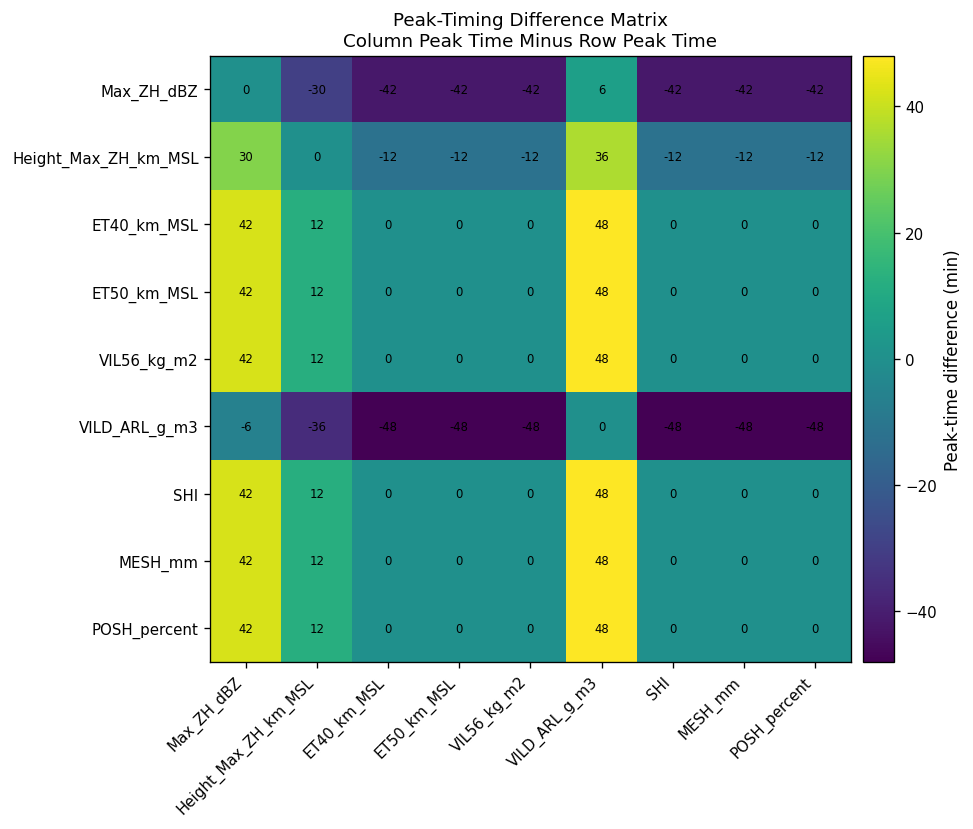

In [22]:
# CELL 22 — Peak-lag matrix figure

if not lag_matrix.empty:

    fig = plt.figure(
        figsize=(
            8.0,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    image = ax.imshow(
        lag_matrix.to_numpy(
            dtype=float
        ),
        aspect="auto",
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Peak-time difference (min)"
    )

    ax.set_xticks(
        np.arange(
            len(
                lag_matrix.columns
            )
        )
    )

    ax.set_xticklabels(
        lag_matrix.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(
        np.arange(
            len(
                lag_matrix.index
            )
        )
    )

    ax.set_yticklabels(
        lag_matrix.index
    )

    for row_i in range(
        len(
            lag_matrix.index
        )
    ):
        for col_i in range(
            len(
                lag_matrix.columns
            )
        ):
            value = (
                lag_matrix.iloc[
                    row_i,
                    col_i,
                ]
            )

            if np.isfinite(
                value
            ):
                ax.text(
                    col_i,
                    row_i,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

    ax.set_title(
        "Peak-Timing Difference Matrix\nColumn Peak Time Minus Row Peak Time"
    )

    F = (
        FIGURE_DIR
        / "09A_fig01_peak_timing_lag_matrix.png"
    )

    save_figure(
        fig,
        F,
        product="peak timing lag matrix",
        units="minutes",
    )

    plt.show()

# 16. Normalize metrics สำหรับเปรียบเทียบ temporal evolution

แต่ละ metric มีหน่วยต่างกัน จึงไม่ควร plot บนแกนเดียวกันโดยใช้ค่าดิบทั้งหมด

Notebook ใช้ min–max normalization ภายใน event:

$$
X^*
=
\frac{
X-X_{min}
}{
X_{max}-X_{min}
}
$$

ได้ช่วง 0–1

นี่มีไว้เพื่อดู **timing and co-evolution**

ไม่ใช่สร้าง severity score และไม่ควรเปรียบเทียบ magnitude ระหว่าง metrics

In [23]:
# CELL 23 — Normalize selected metrics within the event

NORMALIZED_METRICS = [
    metric
    for metric in [
        "Max_ZH_dBZ",
        "ET40_km_MSL",
        "ET50_km_MSL",
        "VIL56_kg_m2",
        "VILD_ARL_g_m3",
        "EchoVolume50_km3",
        "MESH_mm",
    ]
    if metric in (
        CANONICAL.columns
    )
    and CANONICAL[
        metric
    ].notna().any()
]

NORMALIZED = CANONICAL[
    [
        "filename",
        "time_UTC",
        "minutes_from_event_start",
    ]
].copy()

for metric in (
    NORMALIZED_METRICS
):
    values = pd.to_numeric(
        CANONICAL[
            metric
        ],
        errors="coerce",
    )

    minimum = float(
        np.nanmin(
            values
        )
    )

    maximum = float(
        np.nanmax(
            values
        )
    )

    if np.isclose(
        maximum,
        minimum,
    ):
        NORMALIZED[
            metric
        ] = np.where(
            values.notna(),
            0.0,
            np.nan,
        )

    else:
        NORMALIZED[
            metric
        ] = (
            values
            - minimum
        ) / (
            maximum
            - minimum
        )


NORMALIZED_CSV = (
    OUTPUT_CSV_DIR
    / "09A_normalized_lifecycle_table.csv"
)

NORMALIZED.to_csv(
    NORMALIZED_CSV,
    index=False,
)

display(
    NORMALIZED
)

,filename,time_UTC,minutes_from_event_start,Max_ZH_dBZ,ET40_km_MSL,ET50_km_MSL,VIL56_kg_m2,VILD_ARL_g_m3,MESH_mm
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,0.000000,0.987163,0.850227,0.871781,0.660036,0.652364,0.794326
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,5.883333,0.000000,1.000000,1.000000,1.000000,0.463246,1.000000
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,11.883333,0.540281,0.763276,0.129685,0.411437,0.000000,0.714428
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,17.883333,0.777615,0.499659,0.688987,0.768016,0.681544,0.515077
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,23.883333,0.094359,0.495317,0.817406,0.563829,0.318610,0.263874
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,29.883333,0.997718,0.162731,0.000000,0.000000,0.118597,0.228582
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,35.883333,0.663277,0.384806,0.168536,0.130537,0.522265,0.069787
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,41.883333,0.100386,0.000000,0.177950,0.060203,0.055303,0.000000
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,47.883333,1.000000,0.563812,0.762076,0.932038,0.869728,0.392428
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,53.883333,0.697496,0.585233,0.524968,0.892659,1.000000,0.344627


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig02_integrated_normalized_lifecycle.png


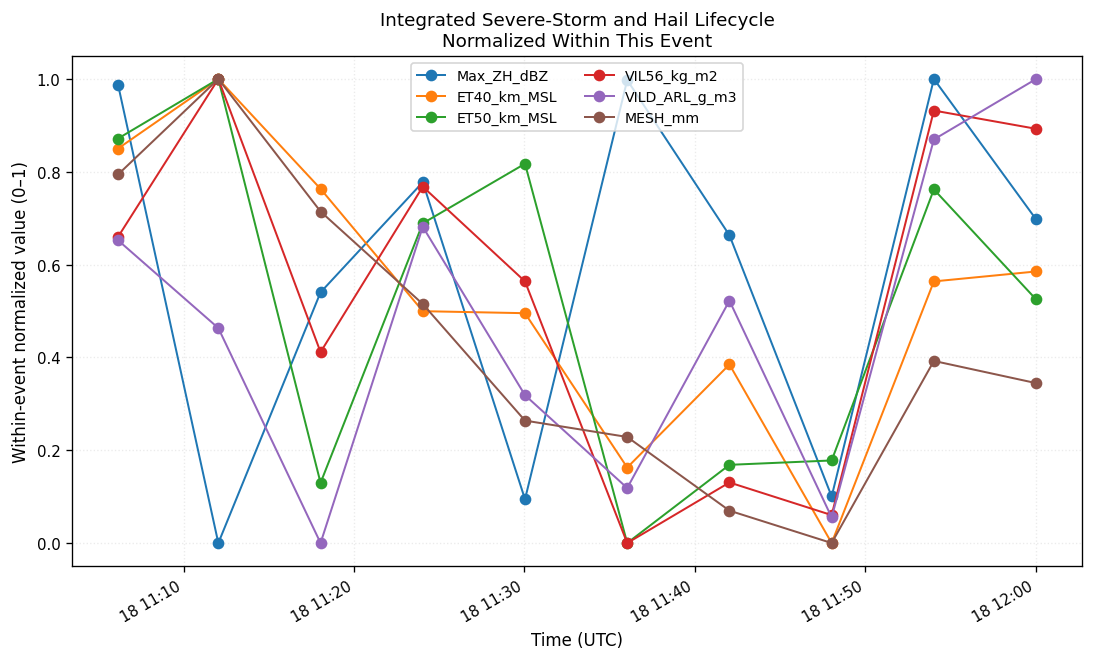

In [24]:
# CELL 24 — Integrated normalized lifecycle figure

fig = plt.figure(
    figsize=(
        9.0,
        5.4,
    )
)

ax = fig.add_subplot(
    111
)

for metric in (
    NORMALIZED_METRICS
):
    ax.plot(
        NORMALIZED[
            "time_UTC"
        ],
        NORMALIZED[
            metric
        ],
        marker="o",
        label=(
            metric
        ),
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Within-event normalized value (0–1)"
)

ax.set_ylim(
    -0.05,
    1.05,
)

ax.set_title(
    "Integrated Severe-Storm and Hail Lifecycle\nNormalized Within This Event"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    loc="best",
    frameon=True,
    ncol=2,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "09A_fig02_integrated_normalized_lifecycle.png"
)

save_figure(
    fig,
    F,
    product="integrated normalized lifecycle",
    interpretation=(
        "Within-event temporal comparison only; not a severity score."
    ),
)

plt.show()

# 17. Severe-core lifecycle figure

ค่าดิบที่แสดงร่วมกันควรมีหน่วยที่เข้ากันได้

ดังนั้น figure นี้เน้น vertical metrics:

```text
Height of maximum ZH
ET40
ET50
```

หน่วยเดียวกันคือ km MSL

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig03_vertical_structure_lifecycle.png


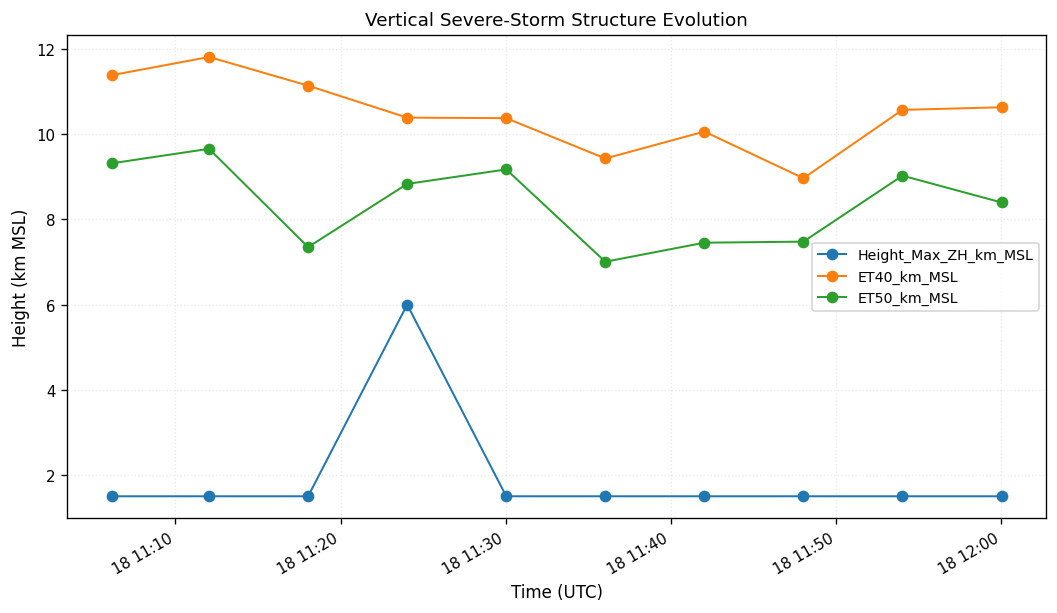

In [25]:
# CELL 25 — Vertical severe-core lifecycle

VERTICAL_METRICS = [
    metric
    for metric in [
        "Height_Max_ZH_km_MSL",
        "ET40_km_MSL",
        "ET50_km_MSL",
    ]
    if metric in (
        CANONICAL.columns
    )
    and CANONICAL[
        metric
    ].notna().any()
]

fig = plt.figure(
    figsize=(
        8.7,
        5.0,
    )
)

ax = fig.add_subplot(
    111
)

for metric in (
    VERTICAL_METRICS
):
    ax.plot(
        CANONICAL[
            "time_UTC"
        ],
        CANONICAL[
            metric
        ],
        marker="o",
        label=(
            metric
        ),
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    "Vertical Severe-Storm Structure Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "09A_fig03_vertical_structure_lifecycle.png"
)

save_figure(
    fig,
    F,
    product="vertical severe-storm lifecycle",
    units="km MSL",
)

plt.show()

# 18. MESH lifecycle

MESH ใช้แกนของตัวเองเพราะหน่วย mm มีความหมายเฉพาะ retrieval

Figure title จะระบุ thermal provenance

กรณีนี้:

```text
REMOTE PROXY SOUNDING
```

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig04_MESH_lifecycle.png


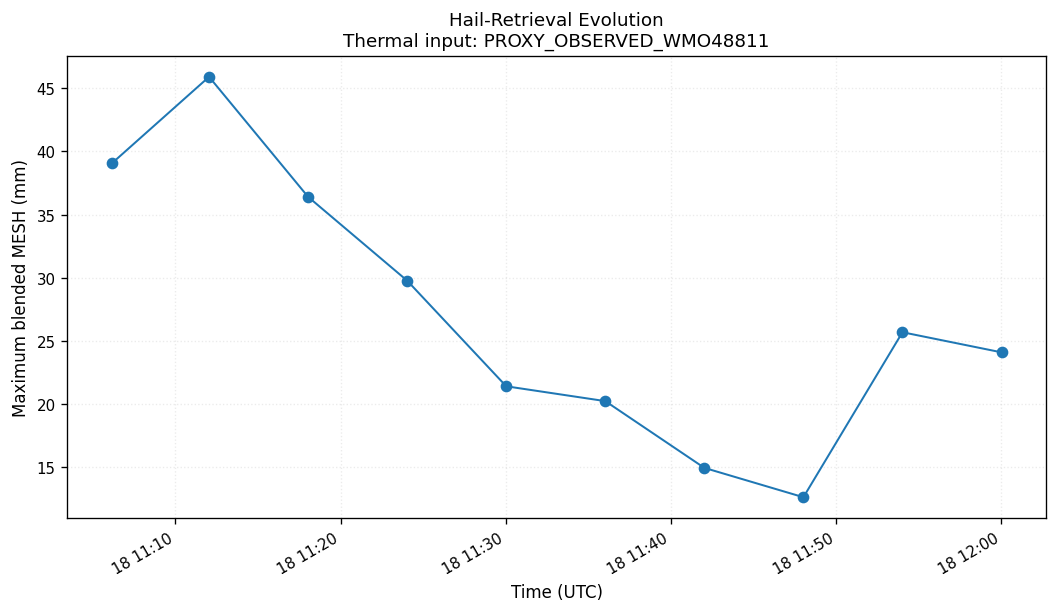

In [26]:
# CELL 26 — MESH lifecycle

if (
    "MESH_mm"
    in CANONICAL.columns
    and CANONICAL[
        "MESH_mm"
    ].notna().any()
):
    fig = plt.figure(
        figsize=(
            8.7,
            5.0,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.plot(
        CANONICAL[
            "time_UTC"
        ],
        CANONICAL[
            "MESH_mm"
        ],
        marker="o",
    )

    ax.set_xlabel(
        "Time (UTC)"
    )

    ax.set_ylabel(
        "Maximum blended MESH (mm)"
    )

    ax.set_title(
        (
            "Hail-Retrieval Evolution\n"
            f"Thermal input: {THERMAL_SOURCE_LABEL}"
        )
    )

    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

    fig.autofmt_xdate()

    F = (
        FIGURE_DIR
        / "09A_fig04_MESH_lifecycle.png"
    )

    save_figure(
        fig,
        F,
        product="MESH lifecycle",
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
        units="mm",
    )

    plt.show()

# 19. Exploratory Spearman association

จำนวน radar volumes ในเหตุการณ์นี้มีเพียงประมาณ 10 scans

ดังนั้น Notebook ใช้ Spearman rank correlation เพื่อการเรียนและ exploratory description เท่านั้น

ไม่ได้ใช้:

- hypothesis testing เพื่ออ้าง population relationship
- p-value เป็นหลักฐานยืนยัน mechanism
- regression model สำหรับ prediction

เกณฑ์ขั้นต่ำใน code:

```text
pairwise valid N ≥ 5
```

In [27]:
# CELL 27 — Exploratory Spearman matrices

CORRELATION_METRICS = [
    metric
    for metric in [
        "Max_ZH_dBZ",
        "Height_Max_ZH_km_MSL",
        "ET40_km_MSL",
        "ET50_km_MSL",
        "VIL56_kg_m2",
        "VILD_ARL_g_m3",
        "EchoVolume50_km3",
        "SHI",
        "MESH_mm",
        "POSH_percent",
    ]
    if metric in (
        CANONICAL.columns
    )
    and CANONICAL[
        metric
    ].notna().any()
]

SPEARMAN_RHO = pd.DataFrame(
    index=CORRELATION_METRICS,
    columns=CORRELATION_METRICS,
    dtype=float,
)

SPEARMAN_N = pd.DataFrame(
    index=CORRELATION_METRICS,
    columns=CORRELATION_METRICS,
    dtype=float,
)

for metric_a in (
    CORRELATION_METRICS
):
    for metric_b in (
        CORRELATION_METRICS
    ):

        # Diagonal: avoid selecting the same DataFrame column twice.
        # dataframe[[metric_a, metric_a]] creates duplicate column names,
        # so pair[metric_a] becomes a DataFrame rather than a Series.
        if metric_a == metric_b:
            series = pd.to_numeric(
                CANONICAL[
                    metric_a
                ],
                errors="coerce",
            ).dropna()

            n_pair = len(
                series
            )

            SPEARMAN_N.loc[
                metric_a,
                metric_b,
            ] = (
                n_pair
            )

            SPEARMAN_RHO.loc[
                metric_a,
                metric_b,
            ] = (
                1.0
                if (
                    n_pair >= 5
                    and series.nunique() >= 2
                )
                else np.nan
            )

            continue

        # Off-diagonal pairs: build uniquely named Series explicitly.
        series_a = pd.to_numeric(
            CANONICAL[
                metric_a
            ],
            errors="coerce",
        )

        series_b = pd.to_numeric(
            CANONICAL[
                metric_b
            ],
            errors="coerce",
        )

        pair = pd.DataFrame({
            "metric_a": (
                series_a
            ),
            "metric_b": (
                series_b
            ),
        }).dropna()

        n_pair = len(
            pair
        )

        SPEARMAN_N.loc[
            metric_a,
            metric_b,
        ] = (
            n_pair
        )

        if n_pair < 5:
            SPEARMAN_RHO.loc[
                metric_a,
                metric_b,
            ] = np.nan
            continue

        if (
            pair[
                "metric_a"
            ].nunique()
            < 2
            or pair[
                "metric_b"
            ].nunique()
            < 2
        ):
            SPEARMAN_RHO.loc[
                metric_a,
                metric_b,
            ] = np.nan
            continue

        rho, _ = spearmanr(
            pair[
                "metric_a"
            ],
            pair[
                "metric_b"
            ],
            nan_policy="omit",
        )

        SPEARMAN_RHO.loc[
            metric_a,
            metric_b,
        ] = float(
            rho
        )


display(
    SPEARMAN_RHO
)

SPEARMAN_RHO_CSV = (
    OUTPUT_CSV_DIR
    / "09A_exploratory_spearman_rho.csv"
)

SPEARMAN_N_CSV = (
    OUTPUT_CSV_DIR
    / "09A_exploratory_spearman_pairwise_N.csv"
)

SPEARMAN_RHO.to_csv(
    SPEARMAN_RHO_CSV,
)

SPEARMAN_N.to_csv(
    SPEARMAN_N_CSV,
)

,Max_ZH_dBZ,Height_Max_ZH_km_MSL,ET40_km_MSL,ET50_km_MSL,VIL56_kg_m2,VILD_ARL_g_m3,SHI,MESH_mm,POSH_percent
Max_ZH_dBZ,1.000000,0.174078,-0.090909,-0.224242,-0.018182,0.478788,-0.018182,-0.018182,-0.018182
Height_Max_ZH_km_MSL,0.174078,1.000000,-0.058026,0.058026,0.174078,0.290129,0.174078,0.174078,0.174078
ET40_km_MSL,-0.090909,-0.058026,1.000000,0.587879,0.745455,0.296970,0.939394,0.939394,0.939394
ET50_km_MSL,-0.224242,0.058026,0.587879,1.000000,0.757576,0.418182,0.587879,0.587879,0.587879
VIL56_kg_m2,-0.018182,0.174078,0.745455,0.757576,1.000000,0.672727,0.696970,0.696970,0.696970
VILD_ARL_g_m3,0.478788,0.290129,0.296970,0.418182,0.672727,1.000000,0.212121,0.212121,0.212121
SHI,-0.018182,0.174078,0.939394,0.587879,0.696970,0.212121,1.000000,1.000000,1.000000
MESH_mm,-0.018182,0.174078,0.939394,0.587879,0.696970,0.212121,1.000000,1.000000,1.000000
POSH_percent,-0.018182,0.174078,0.939394,0.587879,0.696970,0.212121,1.000000,1.000000,1.000000


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig05_exploratory_spearman_matrix.png


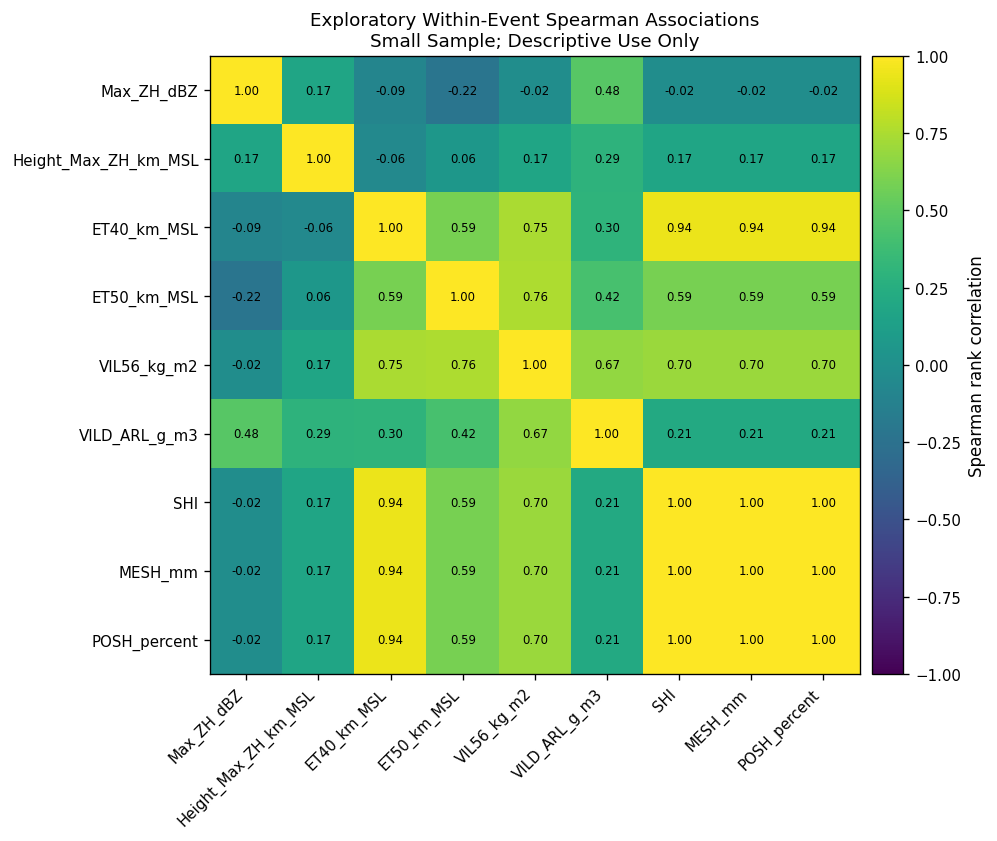

In [28]:
# CELL 28 — Spearman matrix figure

if not SPEARMAN_RHO.empty:

    fig = plt.figure(
        figsize=(
            8.2,
            6.9,
        )
    )

    ax = fig.add_subplot(
        111
    )

    image = ax.imshow(
        SPEARMAN_RHO.to_numpy(
            dtype=float
        ),
        vmin=-1.0,
        vmax=1.0,
        aspect="auto",
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Spearman rank correlation"
    )

    ax.set_xticks(
        np.arange(
            len(
                SPEARMAN_RHO.columns
            )
        )
    )

    ax.set_xticklabels(
        SPEARMAN_RHO.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(
        np.arange(
            len(
                SPEARMAN_RHO.index
            )
        )
    )

    ax.set_yticklabels(
        SPEARMAN_RHO.index
    )

    for row_i in range(
        len(
            SPEARMAN_RHO.index
        )
    ):
        for col_i in range(
            len(
                SPEARMAN_RHO.columns
            )
        ):
            value = (
                SPEARMAN_RHO.iloc[
                    row_i,
                    col_i,
                ]
            )

            if np.isfinite(
                value
            ):
                ax.text(
                    col_i,
                    row_i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

    ax.set_title(
        "Exploratory Within-Event Spearman Associations\nSmall Sample; Descriptive Use Only"
    )

    F = (
        FIGURE_DIR
        / "09A_fig05_exploratory_spearman_matrix.png"
    )

    save_figure(
        fig,
        F,
        product="exploratory Spearman matrix",
        interpretation=(
            "Within-event descriptive association only."
        ),
    )

    plt.show()

# 20. MESH vs VIL และ MESH vs ET50

สอง scatter plots นี้ตอบคนละคำถาม:

```text
MESH vs VIL
→ hail-size retrieval vs vertically integrated reflectivity-derived loading proxy

MESH vs ET50
→ hail-size retrieval vs vertical extent of very strong reflectivity
```

ห้ามตีความว่า VIL หรือ ET50 เป็น ground truth ของ MESH

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig06_MESH_vs_VIL.png


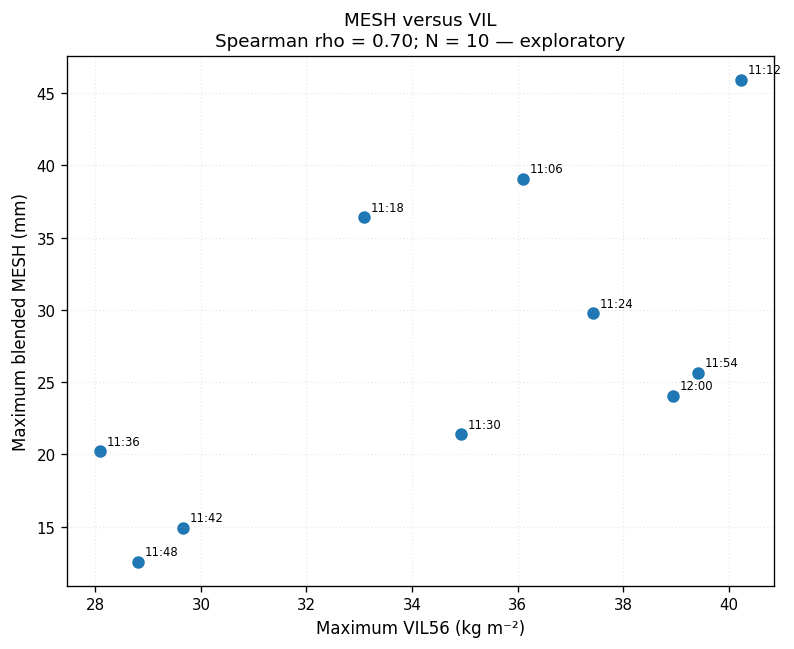

In [29]:
# CELL 29 — Scatter helper

def plot_metric_scatter(
    dataframe,
    *,
    x_metric,
    y_metric,
    x_label,
    y_label,
    title,
    output_path,
):
    pair = dataframe[
        [
            x_metric,
            y_metric,
            "time_UTC",
        ]
    ].dropna()

    fig = plt.figure(
        figsize=(
            6.5,
            5.3,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.scatter(
        pair[
            x_metric
        ],
        pair[
            y_metric
        ],
        s=42,
    )

    for _, row in (
        pair.iterrows()
    ):
        ax.annotate(
            row[
                "time_UTC"
            ].strftime(
                "%H:%M"
            ),
            (
                row[
                    x_metric
                ],
                row[
                    y_metric
                ],
            ),
            xytext=(
                4,
                4,
            ),
            textcoords="offset points",
            fontsize=7,
        )

    rho_text = (
        "rho = n/a"
    )

    if (
        len(
            pair
        )
        >= 5
        and pair[
            x_metric
        ].nunique()
        >= 2
        and pair[
            y_metric
        ].nunique()
        >= 2
    ):
        rho, _ = spearmanr(
            pair[
                x_metric
            ],
            pair[
                y_metric
            ],
        )

        rho_text = (
            f"Spearman rho = {rho:.2f}; "
            f"N = {len(pair)}"
        )

    ax.set_xlabel(
        x_label
    )

    ax.set_ylabel(
        y_label
    )

    ax.set_title(
        title
        + "\n"
        + rho_text
        + " — exploratory"
    )

    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

    save_figure(
        fig,
        output_path,
        product=(
            title
        ),
        interpretation=(
            "Exploratory within-event association."
        ),
    )

    plt.show()


if (
    "MESH_mm"
    in CANONICAL.columns
    and "VIL56_kg_m2"
    in CANONICAL.columns
    and CANONICAL[
        [
            "MESH_mm",
            "VIL56_kg_m2",
        ]
    ].dropna().shape[
        0
    ]
    >= 2
):
    plot_metric_scatter(
        CANONICAL,
        x_metric=(
            "VIL56_kg_m2"
        ),
        y_metric=(
            "MESH_mm"
        ),
        x_label=(
            "Maximum VIL56 (kg m⁻²)"
        ),
        y_label=(
            "Maximum blended MESH (mm)"
        ),
        title=(
            "MESH versus VIL"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig06_MESH_vs_VIL.png"
        ),
    )

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig07_MESH_vs_ET50.png


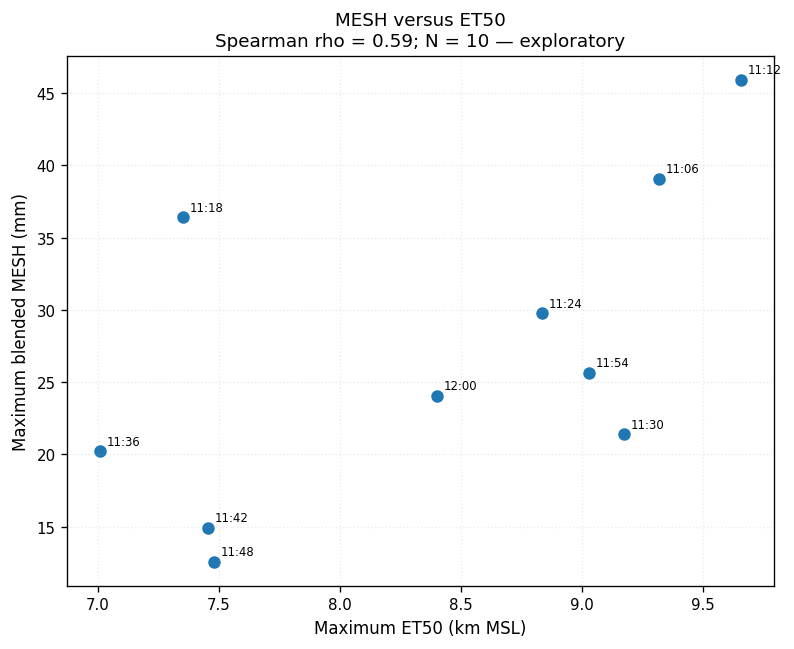

In [30]:
# CELL 30 — MESH versus ET50

if (
    "MESH_mm"
    in CANONICAL.columns
    and "ET50_km_MSL"
    in CANONICAL.columns
    and CANONICAL[
        [
            "MESH_mm",
            "ET50_km_MSL",
        ]
    ].dropna().shape[
        0
    ]
    >= 2
):
    plot_metric_scatter(
        CANONICAL,
        x_metric=(
            "ET50_km_MSL"
        ),
        y_metric=(
            "MESH_mm"
        ),
        x_label=(
            "Maximum ET50 (km MSL)"
        ),
        y_label=(
            "Maximum blended MESH (mm)"
        ),
        title=(
            "MESH versus ET50"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig07_MESH_vs_ET50.png"
        ),
    )

# 21. Peak spatial-product inventory

Integrated event analysis ควร reuse GeoTIFFs ที่สร้างแล้วจาก Notebook 07 และ 08

ผลิตภัณฑ์หลักที่ต้องการ:

```text
Composite ZH
Height of maximum ZH
ET40
ET50
VIL56
VILD18-ARL
MESH blend
```

Notebook จะค้นหาไฟล์ด้วย product tokens เพื่อไม่ผูกกับชื่อไฟล์ย่อยที่เปลี่ยนได้เล็กน้อย

In [31]:
# CELL 31 — Locate peak GeoTIFF products

ALL_TIFS = sorted(
    OUTPUT_GEOTIFF_DIR.glob(
        "*.tif"
    )
)


def find_tif_by_tokens(
    tokens,
    *,
    prefer_prefix=None,
):
    tokens_lower = [
        token.lower()
        for token in (
            tokens
        )
    ]

    matches = []

    for path in (
        ALL_TIFS
    ):
        name_lower = (
            path.name.lower()
        )

        if all(
            token
            in name_lower
            for token in (
                tokens_lower
            )
        ):
            matches.append(
                path
            )

    if (
        prefer_prefix
        is not None
        and matches
    ):
        preferred = [
            path
            for path in (
                matches
            )
            if path.name.startswith(
                prefer_prefix
            )
        ]

        if preferred:
            matches = (
                preferred
            )

    if not matches:
        return None

    return sorted(
        matches
    )[
        -1
    ]


SPATIAL_PRODUCTS = {
    "Composite_ZH": (
        find_tif_by_tokens(
            [
                "composite",
                "zh",
            ],
            prefer_prefix="07",
        )
    ),
    "Height_Max_ZH": (
        find_tif_by_tokens(
            [
                "height",
                "max",
                "zh",
            ],
            prefer_prefix="07",
        )
    ),
    "ET40": (
        find_tif_by_tokens(
            [
                "et40",
            ],
            prefer_prefix="07",
        )
    ),
    "ET50": (
        find_tif_by_tokens(
            [
                "et50",
            ],
            prefer_prefix="07",
        )
    ),
    "VIL56": (
        find_tif_by_tokens(
            [
                "vil56",
            ],
            prefer_prefix="07",
        )
    ),
    "VILD18_ARL": (
        find_tif_by_tokens(
            [
                "vild18",
                "arl",
            ],
            prefer_prefix="07",
        )
    ),
    "MESH_blend": (
        find_tif_by_tokens(
            [
                "mesh",
                "blend",
            ],
            prefer_prefix="08",
        )
    ),
}

SPATIAL_INVENTORY = pd.DataFrame([
    {
        "product": (
            product
        ),
        "available": (
            path
            is not None
            and Path(
                path
            ).exists()
        ),
        "path": (
            str(
                path
            )
            if path
            is not None
            else ""
        ),
    }
    for product, path in (
        SPATIAL_PRODUCTS.items()
    )
])

display(
    SPATIAL_INVENTORY
)

SPATIAL_INVENTORY_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_spatial_product_inventory.csv"
)

SPATIAL_INVENTORY.to_csv(
    SPATIAL_INVENTORY_CSV,
    index=False,
)

,product,available,path
0,Composite_ZH,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
1,Height_Max_ZH,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
2,ET40,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
3,ET50,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
4,VIL56,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
5,VILD18_ARL,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
6,MESH_blend,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


# 22. Spatial alignment check

ก่อนนำหลาย radar products ไปเปรียบเทียบเชิงพื้นที่ ต้องตรวจว่า:

```text
CRS
width
height
transform
```

สอดคล้องกัน

ถ้า raster alignment ต่างกัน ห้าม overlay หรือ subtract โดยตรง

In [32]:
# CELL 32 — Raster alignment diagnostics

alignment_rows = []

for product, path in (
    SPATIAL_PRODUCTS.items()
):
    if (
        path
        is None
        or not Path(
            path
        ).exists()
    ):
        continue

    with rasterio.open(
        path
    ) as src:
        alignment_rows.append({
            "product": (
                product
            ),
            "crs": str(
                src.crs
            ),
            "width": (
                src.width
            ),
            "height": (
                src.height
            ),
            "transform": str(
                src.transform
            ),
            "pixel_width_m": float(
                src.transform.a
            ),
            "pixel_height_m": float(
                abs(
                    src.transform.e
                )
            ),
        })


SPATIAL_ALIGNMENT = pd.DataFrame(
    alignment_rows
)

display(
    SPATIAL_ALIGNMENT
)

SPATIAL_ALIGNMENT_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_spatial_alignment_check.csv"
)

SPATIAL_ALIGNMENT.to_csv(
    SPATIAL_ALIGNMENT_CSV,
    index=False,
)


if len(
    SPATIAL_ALIGNMENT
) >= 2:
    reference = (
        SPATIAL_ALIGNMENT.iloc[
            0
        ]
    )

    SPATIAL_ALIGNMENT_PASS = bool(
        (
            SPATIAL_ALIGNMENT[
                "crs"
            ]
            == reference[
                "crs"
            ]
        ).all()
        and (
            SPATIAL_ALIGNMENT[
                "width"
            ]
            == reference[
                "width"
            ]
        ).all()
        and (
            SPATIAL_ALIGNMENT[
                "height"
            ]
            == reference[
                "height"
            ]
        ).all()
        and (
            SPATIAL_ALIGNMENT[
                "transform"
            ]
            == reference[
                "transform"
            ]
        ).all()
    )

else:
    SPATIAL_ALIGNMENT_PASS = False


print(
    "Spatial alignment:",
    (
        "PASS"
        if SPATIAL_ALIGNMENT_PASS
        else "REVIEW"
    ),
)

,product,crs,width,height,transform,pixel_width_m,pixel_height_m
0,Composite_ZH,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
1,Height_Max_ZH,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
2,ET40,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
3,ET50,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
4,VIL56,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
5,VILD18_ARL,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0
6,MESH_blend,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,"| 500.00, 0.00,-20750.00|\n| 0.00,-500.00, 111...",500.0,500.0


Spatial alignment: PASS


# 23. Storm-reference point in radar-centered Cartesian coordinates

สำหรับ azimuth $\theta$ วัดตาม meteorological convention จากทิศเหนือ:

$$
x
=
r\sin\theta
$$

$$
y
=
r\cos\theta
$$

ใช้เพื่อทำเครื่องหมายตำแหน่งอ้างอิงของ main storm complex บน peak spatial products

ไม่ใช่ observed hail location

In [33]:
# CELL 33 — Storm-reference Cartesian coordinate

theta_rad = np.deg2rad(
    TARGET_AZIMUTH_DEG
)

STORM_REFERENCE_X_KM = (
    CORE_REFERENCE_RANGE_KM
    * np.sin(
        theta_rad
    )
)

STORM_REFERENCE_Y_KM = (
    CORE_REFERENCE_RANGE_KM
    * np.cos(
        theta_rad
    )
)

print(
    "Storm reference x/y:",
    f"{STORM_REFERENCE_X_KM:.1f}, "
    f"{STORM_REFERENCE_Y_KM:.1f} km",
)

Storm reference x/y: 93.2, 26.1 km


# 24. Plot peak spatial products

เพื่อให้ comparison เป็นธรรม:

- ใช้ extent จาก GeoTIFF จริง
- ใช้ km ใน radar-centered Cartesian coordinates
- ทำเครื่องหมาย storm reference point ถ้าอยู่ในขอบเขต raster
- plot แยก product ต่อ figure
- ไม่ resample raster ใหม่ใน Notebook 09A

Notebook 10A จึงค่อยนำ products เหล่านี้ไป overlay กับ administrative boundaries

In [34]:
# CELL 34 — Generic raster plotting helper

def plot_peak_raster(
    path,
    *,
    title,
    colorbar_label,
    output_path,
    product,
):
    path = Path(
        path
    )

    with rasterio.open(
        path
    ) as src:
        data = src.read(
            1,
            masked=True,
        )

        bounds = src.bounds

        extent_km = [
            bounds.left
            / 1000.0,
            bounds.right
            / 1000.0,
            bounds.bottom
            / 1000.0,
            bounds.top
            / 1000.0,
        ]

    fig = plt.figure(
        figsize=(
            7.6,
            6.5,
        )
    )

    ax = fig.add_subplot(
        111
    )

    image = ax.imshow(
        data,
        origin="upper",
        extent=(
            extent_km
        ),
        aspect="equal",
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        colorbar_label
    )

    inside_x = (
        extent_km[
            0
        ]
        <= STORM_REFERENCE_X_KM
        <= extent_km[
            1
        ]
    )

    inside_y = (
        extent_km[
            2
        ]
        <= STORM_REFERENCE_Y_KM
        <= extent_km[
            3
        ]
    )

    legend_needed = False

    if (
        inside_x
        and inside_y
    ):
        ax.scatter(
            [
                STORM_REFERENCE_X_KM
            ],
            [
                STORM_REFERENCE_Y_KM
            ],
            marker="x",
            s=55,
            label="Storm reference",
        )

        legend_needed = True

    if (
        extent_km[
            0
        ]
        <= 0.0
        <= extent_km[
            1
        ]
        and extent_km[
            2
        ]
        <= 0.0
        <= extent_km[
            3
        ]
    ):
        ax.scatter(
            [
                0.0
            ],
            [
                0.0
            ],
            marker="+",
            s=55,
            label="Radar",
        )

        legend_needed = True

    if legend_needed:
        ax.legend(
            frameon=True,
        )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_title(
        title
    )

    ax.grid(
        alpha=0.15,
        linestyle=":",
    )

    save_figure(
        fig,
        output_path,
        product=(
            product
        ),
        source_raster=(
            str(
                path
            )
        ),
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig08_peak_composite_ZH.png


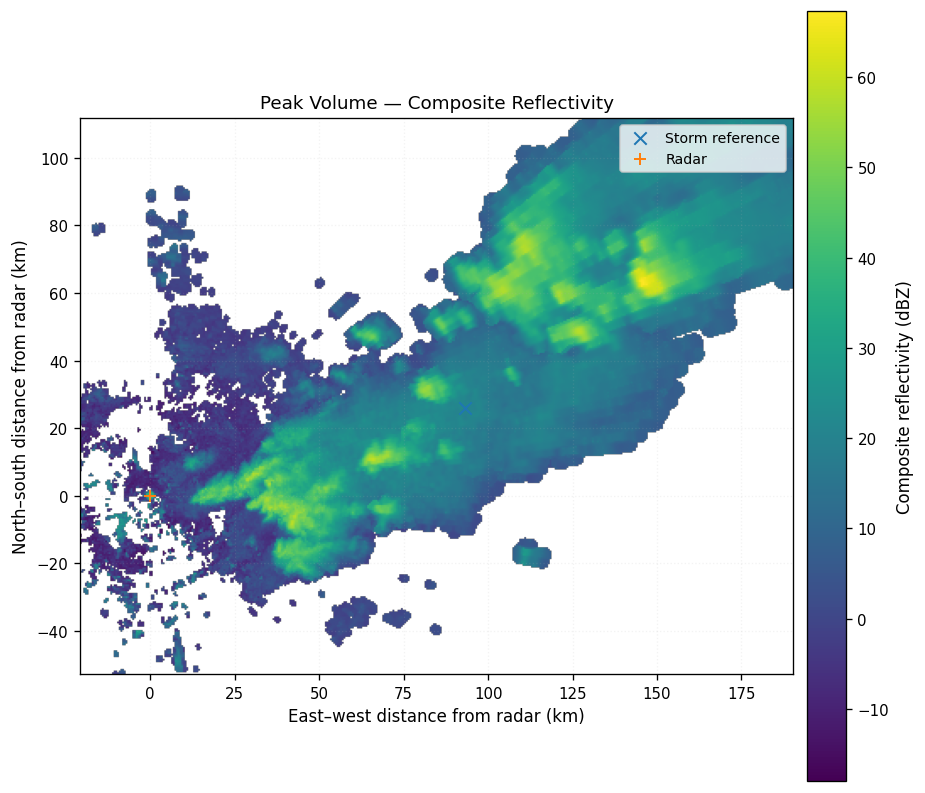

In [35]:
# CELL 35 — Composite reflectivity map

path = (
    SPATIAL_PRODUCTS[
        "Composite_ZH"
    ]
)

if path is not None:
    plot_peak_raster(
        path,
        title=(
            "Peak Volume — Composite Reflectivity"
        ),
        colorbar_label=(
            "Composite reflectivity (dBZ)"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig08_peak_composite_ZH.png"
        ),
        product=(
            "Composite reflectivity"
        ),
    )
else:
    print(
        "Composite ZH raster not found."
    )

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig09_peak_ET50.png


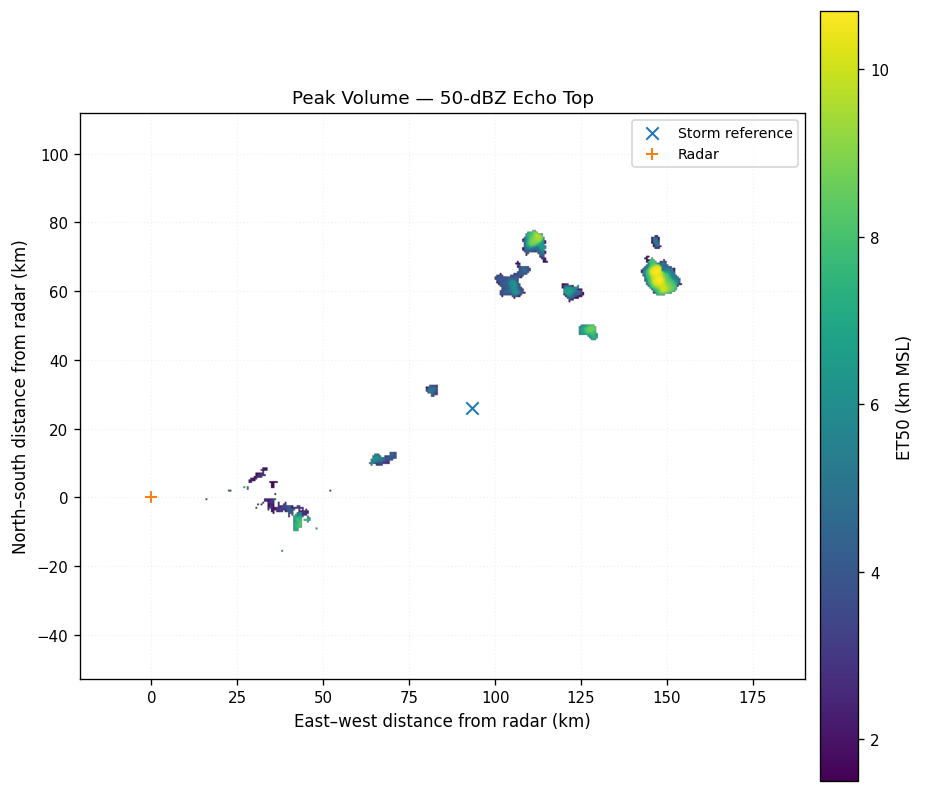

In [36]:
# CELL 36 — ET50 map

path = (
    SPATIAL_PRODUCTS[
        "ET50"
    ]
)

if path is not None:
    plot_peak_raster(
        path,
        title=(
            "Peak Volume — 50-dBZ Echo Top"
        ),
        colorbar_label=(
            "ET50 (km MSL)"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig09_peak_ET50.png"
        ),
        product=(
            "ET50"
        ),
    )
else:
    print(
        "ET50 raster not found."
    )

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig10_peak_VIL56.png


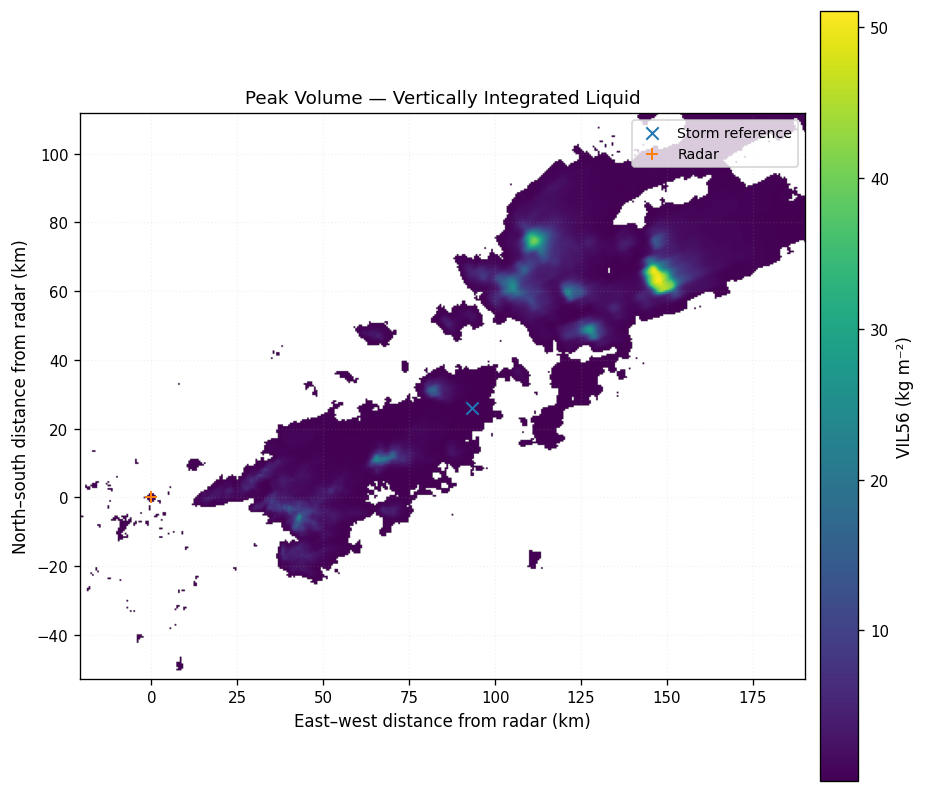

In [37]:
# CELL 37 — VIL56 map

path = (
    SPATIAL_PRODUCTS[
        "VIL56"
    ]
)

if path is not None:
    plot_peak_raster(
        path,
        title=(
            "Peak Volume — Vertically Integrated Liquid"
        ),
        colorbar_label=(
            "VIL56 (kg m⁻²)"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig10_peak_VIL56.png"
        ),
        product=(
            "VIL56"
        ),
    )
else:
    print(
        "VIL56 raster not found."
    )

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/09A/09A_fig11_peak_MESH_blend.png


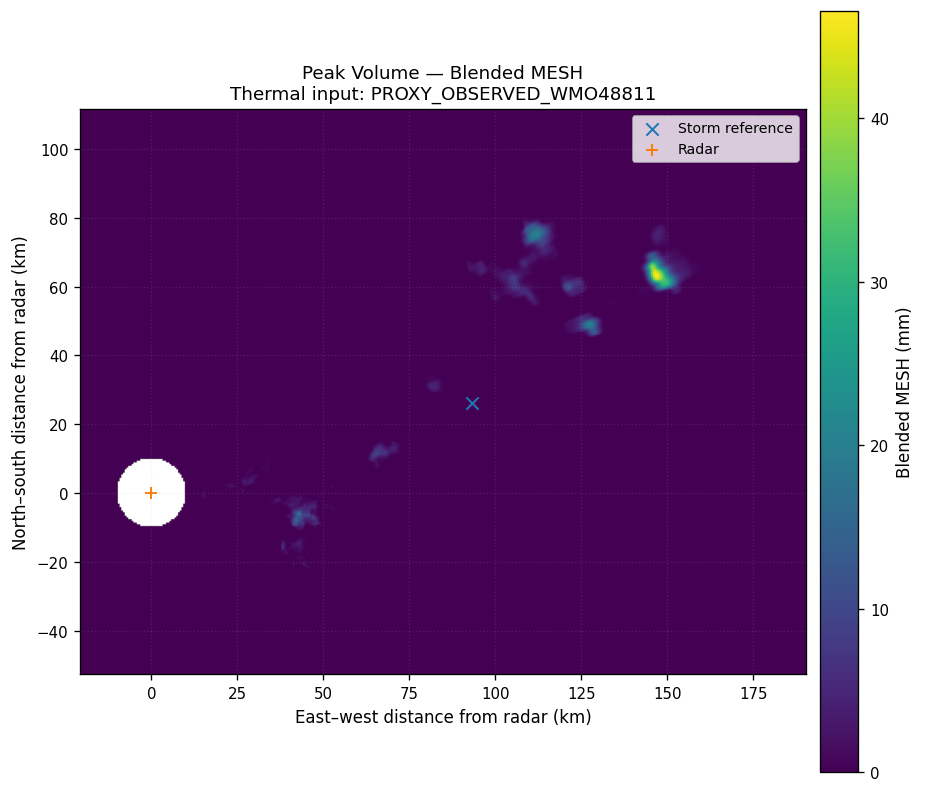

In [38]:
# CELL 38 — Blended MESH map

path = (
    SPATIAL_PRODUCTS[
        "MESH_blend"
    ]
)

if path is not None:
    plot_peak_raster(
        path,
        title=(
            "Peak Volume — Blended MESH\n"
            f"Thermal input: {THERMAL_SOURCE_LABEL}"
        ),
        colorbar_label=(
            "Blended MESH (mm)"
        ),
        output_path=(
            FIGURE_DIR
            / "09A_fig11_peak_MESH_blend.png"
        ),
        product=(
            "MESH blend"
        ),
    )
else:
    print(
        "Blended MESH raster not found."
    )

# 25. สิ่งที่ต้องสังเกตจาก spatial products

นิสิตควรเปรียบเทียบ:

```text
Composite ZH maximum
ET50 maximum
VIL maximum
MESH maximum
```

คำถามสำคัญ:

1. maxima อยู่บริเวณเดียวกันหรือไม่?
2. footprint ของ ET50 เล็กกว่า composite ZH หรือไม่?
3. MESH maximum ซ้อนกับ high VIL หรือ high ET50 หรือไม่?
4. มีบริเวณ high reflectivity ที่ MESH ต่ำหรือไม่?
5. geometry ของ product ถูกตัดด้วย grid edge หรือไม่?

คำตอบจากแผนที่เป็น spatial association ไม่ใช่ validation

# 26. Event synthesis relative to the MESH peak

เพื่อสร้าง Results narrative ที่อ่านง่าย จะใช้ MESH peak เป็น hail-retrieval reference time

แล้วคำนวณ:

$$
\Delta t
=
t_{peak,metric}
-
t_{peak,MESH}
$$

ค่าลบ = metric peak ก่อน MESH  
ค่าบวก = metric peak หลัง MESH

นี่เป็น descriptive reference ไม่ได้หมายความว่า MESH เป็นตัวแปรเหตุ

In [39]:
# CELL 39 — Peak timing relative to MESH

mesh_peak_rows = (
    PEAK_TIMING.loc[
        PEAK_TIMING[
            "metric"
        ]
        == "MESH_mm"
    ]
)

if (
    mesh_peak_rows.empty
    or mesh_peak_rows[
        "peak_time_UTC"
    ].isna().all()
):
    MESH_PEAK_TIME_UTC = pd.NaT

else:
    MESH_PEAK_TIME_UTC = (
        mesh_peak_rows.iloc[
            0
        ][
            "peak_time_UTC"
        ]
    )


PEAK_RELATIVE_TO_MESH = (
    PEAK_TIMING.copy()
)

if pd.notna(
    MESH_PEAK_TIME_UTC
):
    PEAK_RELATIVE_TO_MESH[
        "minutes_relative_to_MESH_peak"
    ] = (
        PEAK_RELATIVE_TO_MESH[
            "peak_time_UTC"
        ]
        - MESH_PEAK_TIME_UTC
    ).dt.total_seconds() / 60.0

else:
    PEAK_RELATIVE_TO_MESH[
        "minutes_relative_to_MESH_peak"
    ] = np.nan


display(
    PEAK_RELATIVE_TO_MESH
)

PEAK_RELATIVE_TO_MESH_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_timing_relative_to_MESH.csv"
)

PEAK_RELATIVE_TO_MESH.to_csv(
    PEAK_RELATIVE_TO_MESH_CSV,
    index=False,
)

,metric,maximum_value,peak_time_UTC,minutes_from_event_start,available_scan_count,minutes_relative_to_MESH_peak
0,Max_ZH_dBZ,62.783833,2023-03-18 11:54:02+00:00,47.883333,10,42.0
1,Height_Max_ZH_km_MSL,6.000000,2023-03-18 11:24:02+00:00,17.883333,10,12.0
2,ET40_km_MSL,11.815581,2023-03-18 11:12:02+00:00,5.883333,10,0.0
3,ET50_km_MSL,9.659167,2023-03-18 11:12:02+00:00,5.883333,10,0.0
4,VIL56_kg_m2,40.245372,2023-03-18 11:12:02+00:00,5.883333,10,0.0
5,VILD_ARL_g_m3,3.538617,2023-03-18 12:00:02+00:00,53.883333,10,48.0
6,Core40_area_km2,NaN,NaT,NaN,0,NaN
7,Footprint50_area_km2,NaN,NaT,NaN,0,NaN
8,EchoVolume40_km3,NaN,NaT,NaN,0,NaN
9,EchoVolume50_km3,NaN,NaT,NaN,0,NaN


# 27. Scan-by-scan event synthesis

ตารางนี้รวมค่าหลักที่เหมาะกับ Results section:

```text
time
Max ZH
ET40
ET50
VIL
VILD
MESH
```

การอ่านควรเน้น temporal pattern ไม่ใช่ไล่ตัวเลขทุกช่อง

In [40]:
# CELL 40 — Compact event-synthesis table

SYNTHESIS_COLUMNS = [
    "time_UTC",
    "Max_ZH_dBZ",
    "ET40_km_MSL",
    "ET50_km_MSL",
    "VIL56_kg_m2",
    "VILD_ARL_g_m3",
    "EchoVolume50_km3",
    "MESH_mm",
    "POSH_percent",
]

SYNTHESIS_COLUMNS = [
    column
    for column in (
        SYNTHESIS_COLUMNS
    )
    if column in (
        CANONICAL.columns
    )
]

EVENT_SYNTHESIS = CANONICAL[
    SYNTHESIS_COLUMNS
].copy()

display(
    EVENT_SYNTHESIS
)

EVENT_SYNTHESIS_CSV = (
    OUTPUT_CSV_DIR
    / "09A_event_synthesis_table.csv"
)

EVENT_SYNTHESIS.to_csv(
    EVENT_SYNTHESIS_CSV,
    index=False,
)

,time_UTC,Max_ZH_dBZ,ET40_km_MSL,ET50_km_MSL,VIL56_kg_m2,VILD_ARL_g_m3,EchoVolume50_km3,MESH_mm,POSH_percent
0,2023-03-18 11:06:09+00:00,62.715824,11.389129,9.319166,36.108621,3.285499,NaN,39.060818,70.919686
1,2023-03-18 11:12:02+00:00,57.486195,11.815581,9.659167,40.245372,3.147801,NaN,45.915013,80.011865
2,2023-03-18 11:18:02+00:00,60.348408,11.141554,7.351337,33.083617,2.810506,NaN,36.398183,66.879697
3,2023-03-18 11:24:02+00:00,61.605717,10.390952,8.834447,37.422540,3.306746,NaN,29.754708,55.253881
4,2023-03-18 11:30:02+00:00,57.986076,10.378588,9.174979,34.937959,3.042490,NaN,21.383248,36.114057
5,2023-03-18 11:36:02+00:00,62.771744,9.431610,7.007449,28.077171,2.896857,NaN,20.207126,32.834138
6,2023-03-18 11:42:02+00:00,60.999996,10.063929,7.454358,29.665576,3.190773,NaN,14.915199,15.225378
7,2023-03-18 11:48:02+00:00,58.018002,8.968264,7.479322,28.809731,2.850773,NaN,12.589516,5.393807
8,2023-03-18 11:54:02+00:00,62.783833,10.573615,9.028258,39.418396,3.443765,NaN,25.667389,46.698056
9,2023-03-18 12:00:02+00:00,61.181274,10.634607,8.399517,38.939225,3.538617,NaN,24.074398,42.985327


# 28. Auto-generated factual summary

Notebook จะสร้างเฉพาะ **factual numerical summary**

ไม่สร้าง causal explanation อัตโนมัติ

ตัวอย่าง output:

```text
Maximum ZH occurred at ...
Maximum ET50 occurred at ...
Maximum VIL occurred at ...
Maximum MESH occurred at ...
```

จากนั้นนิสิตต้องใช้ physical understanding จาก Notebook 06–08 เพื่ออภิปรายเอง

In [41]:
# CELL 41 — Factual event summary

SUMMARY_METRICS = [
    "Max_ZH_dBZ",
    "ET40_km_MSL",
    "ET50_km_MSL",
    "VIL56_kg_m2",
    "VILD_ARL_g_m3",
    "EchoVolume50_km3",
    "MESH_mm",
]

summary_lines = []

for metric in (
    SUMMARY_METRICS
):
    row = PEAK_TIMING.loc[
        PEAK_TIMING[
            "metric"
        ]
        == metric
    ]

    if (
        row.empty
        or pd.isna(
            row.iloc[
                0
            ][
                "peak_time_UTC"
            ]
        )
    ):
        continue

    record = (
        row.iloc[
            0
        ]
    )

    summary_lines.append(
        (
            f"{metric}: maximum = "
            f"{record['maximum_value']:.3f}; "
            f"peak time = "
            f"{record['peak_time_UTC'].strftime('%H:%M:%S UTC')}; "
            f"{record['minutes_from_event_start']:.1f} min "
            f"from event start."
        )
    )


FACTUAL_SUMMARY_TEXT = "\n".join(
    summary_lines
)

print(
    FACTUAL_SUMMARY_TEXT
)


FACTUAL_SUMMARY_TXT = (
    OUTPUT_CSV_DIR.parent
    / "09A_event_factual_summary.txt"
)

FACTUAL_SUMMARY_TXT.write_text(
    FACTUAL_SUMMARY_TEXT,
    encoding="utf-8",
)

Max_ZH_dBZ: maximum = 62.784; peak time = 11:54:02 UTC; 47.9 min from event start.
ET40_km_MSL: maximum = 11.816; peak time = 11:12:02 UTC; 5.9 min from event start.
ET50_km_MSL: maximum = 9.659; peak time = 11:12:02 UTC; 5.9 min from event start.
VIL56_kg_m2: maximum = 40.245; peak time = 11:12:02 UTC; 5.9 min from event start.
VILD_ARL_g_m3: maximum = 3.539; peak time = 12:00:02 UTC; 53.9 min from event start.
MESH_mm: maximum = 45.915; peak time = 11:12:02 UTC; 5.9 min from event start.


494

# 29. แนวทางอภิปรายเชิงกายภาพ

ใช้คำถามแทนการสรุปแบบอัตโนมัติ:

### Horizontal intensification

- Max ZH เพิ่มขึ้นเมื่อใด?
- severe-core footprint ขยายหรือหดเมื่อใด?

### Vertical development

- ET40 และ ET50 เพิ่มก่อนหรือหลัง Max ZH?
- height of maximum ZH ยกตัวขึ้นหรือไม่?

### Column loading

- VIL เพิ่มพร้อมกับ ET50 หรือไม่?
- VILD เปลี่ยนเหมือน VIL หรือไม่?

### Hail retrieval

- MESH peak เวลาเดียวกับ ET50 หรือไม่?
- MESH footprint สอดคล้องกับ severe core หรือไม่?

### Decay

- metric ใดลดลงก่อน?
- strong reflectivity ยังอยู่ขณะที่ MESH ลดลงหรือไม่?

คำตอบควรอิงผลจริงจากตารางและ figure ไม่ควรบังคับให้เข้ากับ conceptual model

# 30. แนวทางเขียน Methods สำหรับ Notebook 09A

Methods ควรรายงานว่า Notebook นี้เป็น **integration step** ไม่ใช่ algorithm-development step

ตัวอย่าง:

> Event-scale severe-storm and hail diagnostics were integrated from previously generated radar products. Severe-core metrics, including maximum reflectivity, echo-top heights, vertically integrated liquid, vertically integrated liquid density, severe-core area and echo volumes, were obtained from the three-dimensional storm analysis. Hail-specific metrics, including SHI, MESH and POSH, were obtained from the pyhail workflow using the documented thermal input from Notebook 08. Metrics were aligned by radar-volume filename and UTC timestamp. Peak timing and pairwise peak-time differences were calculated descriptively. Selected metrics were min–max normalized within the event solely to compare temporal evolution. Spearman rank correlations were treated as exploratory because the event contained only a small number of radar volumes.

ต้องเพิ่ม thermal-input limitation จาก Notebook 08 ด้วย

# 31. แนวทางเขียน Results

Results ที่ดีควรจัดตาม physical sequence เช่น:

### Horizontal storm intensity

- maximum reflectivity
- severe-core area
- 50-dBZ footprint

### Vertical development

- height of maximum reflectivity
- ET40
- ET50

### Column-integrated structure

- VIL
- VILD
- 40/50-dBZ echo volume

### Hail retrieval

- SHI
- MESH
- POSH

### Temporal synthesis

- peak order
- peak-time differences
- descriptive associations

ไม่ควรรายงานทุกค่าในทุก scan เป็นข้อความยาว

# 32. CORE — แบบฝึกหัดสำหรับปริญญาตรี

### Exercise 1 — Peak order

ใช้ `09A_peak_timing_order.csv`

ตอบ:

- metric ใด peak ก่อน?
- metric ใด peak หลัง?
- Max ZH, ET50, VIL และ MESH peak พร้อมกันหรือไม่?

### Exercise 2 — Normalized lifecycle

จาก Figure 09A_fig02:

- metric ใดเพิ่มเร็วที่สุด?
- metric ใดลดก่อน?
- มีช่วงใดที่ ET50 สูงแต่ MESH เริ่มลดหรือไม่?

### Exercise 3 — Spatial comparison

เปรียบเทียบ:

```text
Composite ZH
ET50
VIL
MESH
```

แล้วอธิบายว่าทำไม footprint ไม่จำเป็นต้องเหมือนกัน

### Exercise 4 — Observation versus retrieval

อธิบายความต่าง:

```text
Observed-hail event
Radar severe-core metric
MESH estimate
Observed hailstone size
```

# 33. ADVANCED / MSc — แบบฝึกหัด

### Exercise 5 — Peak-lag interpretation

ใช้ `09A_peak_lag_matrix_minutes.csv`

เลือก 3 คู่:

```text
Max ZH → ET50
ET50 → VIL
VIL → MESH
```

อธิบายว่าค่า lag บอกอะไร และอะไรที่บอกไม่ได้

### Exercise 6 — Exploratory correlation

ใช้ `09A_exploratory_spearman_rho.csv`

หา metric ที่สัมพันธ์กับ MESH สูงที่สุดภายในเหตุการณ์นี้

จากนั้นอธิบายว่าเหตุใดไม่ควร generalize ไปยัง climatology

### Exercise 7 — Proxy sounding limitation

อภิปรายว่า thermal provenance จาก Dien Bien Phu อาจมีผลต่อ interpretation ของ MESH อย่างไร

### Exercise 8 — Research design

ถ้ามี 50 observed-hail events:

ออกแบบ analysis เพื่อทดสอบว่า ET50 หรือ VIL มีความสัมพันธ์กับ MESH อย่างสม่ำเสมอหรือไม่

# 34. RESEARCH NOTE — สิ่งที่ Notebook 09A ยังไม่ทำ

Notebook นี้ยัง **ไม่**:

- validate MESH กับ observed hail diameter
- derive causal storm physics from one event
- classify storm type objectively
- compute population-level significance
- overlay administrative exposure
- estimate population/infrastructure impacts
- calibrate Thailand hail thresholds

สิ่งเหล่านี้เป็นหัวข้อของ Notebook 10A–11A หรือ research dataset ที่ใหญ่กว่า

# 35. ทางต่อไป — Notebook 10A

Notebook 10A จะเปลี่ยนจาก:

```text
storm-centric analysis
```

ไปเป็น:

```text
GIS exposure analysis
```

แนวคิด:

```text
Peak / event-maximum radar hazard products
        +
ADM1 / ADM2 boundaries
        ↓
Zonal statistics
        ↓
Administrative exposure
        ↓
Storm-track intersection
```

ตัวแปรที่ใช้:

```text
MESH
ET40 / ET50
VIL / VILD
Composite ZH
Severe-core footprint
```

โดยย้ำว่า:

```text
administrative exposure ≠ verified damage
```

# 36. Export processing metadata

In [42]:
# CELL 42 — Processing metadata

PROCESSING_METADATA_09A = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "analysis_track",
        "analysis_name",
        "radar_site",
        "radar_latitude_deg",
        "radar_longitude_deg",
        "radar_altitude_m_MSL",
        "severe_metrics_source",
        "hail_metrics_source",
        "thermal_input_mode",
        "thermal_source_label",
        "integrated_scan_count",
        "event_start_UTC",
        "event_end_UTC",
        "event_duration_minutes",
        "peak_reference_metric",
        "normalized_lifecycle_used",
        "normalization_method",
        "spearman_analysis",
        "spearman_min_pairwise_N",
        "spearman_interpretation",
        "peak_lag_interpretation",
        "spatial_alignment_pass",
        "QPE_context_ready",
        "local_hail_size_validation",
        "causal_inference_performed",
        "main_interpretation",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        "A",
        "Integrated severe-storm and hail event analysis",
        "Omkoi",
        RADAR_LAT,
        RADAR_LON,
        RADAR_ALTITUDE_M_MSL,
        str(
            LIFECYCLE_07_CSV
        ),
        str(
            MESH_LIFECYCLE_08_CSV
        ),
        THERMAL_INPUT_MODE,
        THERMAL_SOURCE_LABEL,
        len(
            CANONICAL
        ),
        str(
            CANONICAL[
                "time_UTC"
            ].min()
        ),
        str(
            CANONICAL[
                "time_UTC"
            ].max()
        ),
        float(
            (
                CANONICAL[
                    "time_UTC"
                ].max()
                - CANONICAL[
                    "time_UTC"
                ].min()
            ).total_seconds()
            / 60.0
        ),
        "MESH peak for descriptive relative timing only",
        True,
        "within-event min-max scaling",
        True,
        5,
        "exploratory descriptive association only",
        "descriptive timing difference only; not causal lead-lag evidence",
        SPATIAL_ALIGNMENT_PASS,
        QPE_CONTEXT_READY,
        False,
        False,
        (
            "Integration of severe-storm structure and radar-derived hail diagnostics "
            "for one independently known observed-hail event."
        ),
    ],
})

display(
    PROCESSING_METADATA_09A
)

PROCESSING_METADATA_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_processing_metadata.csv"
)

PROCESSING_METADATA_09A.to_csv(
    PROCESSING_METADATA_09A_CSV,
    index=False,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,analysis_track,A
3,analysis_name,Integrated severe-storm and hail event analysis
4,radar_site,Omkoi
5,radar_latitude_deg,17.798207
6,radar_longitude_deg,98.432326
7,radar_altitude_m_MSL,1173.0
8,severe_metrics_source,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
9,hail_metrics_source,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


# 37. Export figure manifest

In [43]:
# CELL 43 — Figure manifest

FIGURE_MANIFEST_09A = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_figure_manifest.csv"
)

FIGURE_MANIFEST_09A.to_csv(
    FIGURE_MANIFEST_09A_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST_09A
)

,figure_name,figure_path,product,units,dpi,interpretation,thermal_source,source_raster
0,09A_fig01_peak_timing_lag_matrix.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,peak timing lag matrix,minutes,300,NaN,NaN,NaN
1,09A_fig02_integrated_normalized_lifecycle.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,integrated normalized lifecycle,NaN,300,Within-event temporal comparison only; not a s...,NaN,NaN
2,09A_fig03_vertical_structure_lifecycle.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,vertical severe-storm lifecycle,km MSL,300,NaN,NaN,NaN
3,09A_fig04_MESH_lifecycle.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH lifecycle,mm,300,NaN,PROXY_OBSERVED_WMO48811,NaN
4,09A_fig05_exploratory_spearman_matrix.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,exploratory Spearman matrix,NaN,300,Within-event descriptive association only.,NaN,NaN
5,09A_fig06_MESH_vs_VIL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH versus VIL,NaN,300,Exploratory within-event association.,NaN,NaN
6,09A_fig07_MESH_vs_ET50.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH versus ET50,NaN,300,Exploratory within-event association.,NaN,NaN
7,09A_fig08_peak_composite_ZH.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,Composite reflectivity,NaN,300,NaN,NaN,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
8,09A_fig09_peak_ET50.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET50,NaN,300,NaN,NaN,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
9,09A_fig10_peak_VIL56.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,VIL56,NaN,300,NaN,NaN,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


# 38. Output inventory

In [44]:
# CELL 44 — Output inventory

EXPECTED_OUTPUTS = [
    INTEGRATED_LIFECYCLE_CSV,
    PEAK_TIMING_CSV,
    PEAK_ORDER_CSV,
    PEAK_LAG_MATRIX_CSV,
    NORMALIZED_CSV,
    SPEARMAN_RHO_CSV,
    SPEARMAN_N_CSV,
    SPATIAL_INVENTORY_CSV,
    SPATIAL_ALIGNMENT_CSV,
    PEAK_RELATIVE_TO_MESH_CSV,
    EVENT_SYNTHESIS_CSV,
    FACTUAL_SUMMARY_TXT,
    PROCESSING_METADATA_09A_CSV,
    FIGURE_MANIFEST_09A_CSV,
]

OUTPUT_INVENTORY_09A = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    OUTPUT_INVENTORY_09A
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 39. Final readiness

Notebook 09A ผ่านเมื่อ:

```text
03 / 07 / 08 readiness PASS
severe + hail lifecycle merge ครบ
canonical lifecycle มีข้อมูล
MESH lifecycle มีข้อมูล
peak timing สร้างได้
thermal provenance ถูกอ่าน
spatial inventory ถูกสร้าง
processing metadata ถูก export
```

Spatial alignment อาจขึ้น REVIEW หากบาง raster หาไม่พบ  
แต่ lifecycle integration ยังสามารถผ่านได้ถ้าข้อมูล temporal ครบ

In [45]:
# CELL 45 — Notebook 09A readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 03 readiness",
    readiness_passed(
        readiness_03
    ),
)

add_check(
    "Notebook 07 readiness",
    readiness_passed(
        readiness_07
    ),
)

add_check(
    "Notebook 08 readiness",
    readiness_passed(
        readiness_08
    ),
)

add_check(
    "Observed-hail event active",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Severe lifecycle available",
    len(
        SEVERE_07
    )
    > 0,
)

add_check(
    "Hail lifecycle available",
    len(
        HAIL_08
    )
    > 0,
)

add_check(
    "Lifecycle tables merged one-to-one",
    len(
        CANONICAL
    )
    == len(
        SEVERE_07
    )
    == len(
        HAIL_08
    ),
)

add_check(
    "Integrated lifecycle has at least 5 scans",
    len(
        CANONICAL
    )
    >= 5,
)

add_check(
    "MESH available in integrated lifecycle",
    (
        "MESH_mm"
        in CANONICAL.columns
        and CANONICAL[
            "MESH_mm"
        ].notna().any()
    ),
)

add_check(
    "ET50 available",
    (
        "ET50_km_MSL"
        in CANONICAL.columns
        and CANONICAL[
            "ET50_km_MSL"
        ].notna().any()
    ),
)

add_check(
    "VIL available",
    (
        "VIL56_kg_m2"
        in CANONICAL.columns
        and CANONICAL[
            "VIL56_kg_m2"
        ].notna().any()
    ),
)

add_check(
    "Thermal provenance available",
    THERMAL_PROVENANCE_08_CSV.exists(),
    (
        f"{THERMAL_INPUT_MODE} | "
        f"{THERMAL_SOURCE_LABEL}"
    ),
)

add_check(
    "Peak timing table exported",
    PEAK_TIMING_CSV.exists(),
)

add_check(
    "Peak-lag matrix exported",
    PEAK_LAG_MATRIX_CSV.exists(),
)

add_check(
    "Exploratory Spearman matrix exported",
    SPEARMAN_RHO_CSV.exists(),
)

add_check(
    "Spatial product inventory exported",
    SPATIAL_INVENTORY_CSV.exists(),
    (
        "Spatial alignment PASS"
        if SPATIAL_ALIGNMENT_PASS
        else "Spatial rasters require review or some products are unavailable."
    ),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_09A_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_09A_CSV.exists(),
)


READINESS_09A = pd.DataFrame(
    checks
)

display(
    READINESS_09A
)

NOTEBOOK_09A_READY = bool(
    (
        READINESS_09A[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_readiness_check.csv"
)

READINESS_09A.to_csv(
    READINESS_09A_CSV,
    index=False,
)

print()

if NOTEBOOK_09A_READY:
    print(
        "NOTEBOOK 09A INTEGRATED SEVERE-STORM AND HAIL EVENT ANALYSIS READY"
    )

    print(
        "Next step: Notebook 10A — GIS Exposure and Administrative Analysis"
    )

else:
    print(
        "NOTEBOOK 09A REQUIRES REVIEW"
    )

,item,status,note
0,Notebook 03 readiness,PASS,
1,Notebook 07 readiness,PASS,
2,Notebook 08 readiness,PASS,
3,Observed-hail event active,PASS,
4,Severe lifecycle available,PASS,
5,Hail lifecycle available,PASS,
6,Lifecycle tables merged one-to-one,PASS,
7,Integrated lifecycle has at least 5 scans,PASS,
8,MESH available in integrated lifecycle,PASS,
9,ET50 available,PASS,



NOTEBOOK 09A INTEGRATED SEVERE-STORM AND HAIL EVENT ANALYSIS READY
Next step: Notebook 10A — GIS Exposure and Administrative Analysis


# ข้อความสำคัญที่ต้องจำ

1. Notebook 09A เป็น integration step ไม่ใช่ algorithm-development step
2. severe metrics มาจาก Notebook 07
3. hail metrics มาจาก Notebook 08
4. thermal provenance ของ MESH ต้องถูกเก็บไว้เสมอ
5. observed-hail event ไม่ใช่ pixel-level hail truth
6. MESH ไม่ใช่ observed hail diameter
7. normalized lifecycle ใช้เปรียบเทียบ timing ไม่ใช่ severity score
8. peak-time lag เป็น descriptive timing difference
9. correlation จากประมาณ 10 scans เป็น exploratory เท่านั้น
10. Spearman correlation ไม่พิสูจน์ causal mechanism
11. ET50 ไม่ใช่ cloud top
12. VIL ไม่ใช่ hail mass truth
13. VILD ไม่ใช่ locally validated Thailand hail threshold
14. spatial overlap ไม่ใช่ validation
15. peak metrics ไม่จำเป็นต้องเกิดเวลาเดียวกัน
16. radar product footprints ต้องตรวจ CRS/transform ก่อนเปรียบเทียบ
17. QPE accumulation มี temporal support ต่างจาก instantaneous severe metrics
18. proxy sounding limitation จาก Notebook 08 ต้องตามไปใน interpretation
19. Notebook 10A จะเปลี่ยนจาก storm-centric เป็น administrative exposure
20. administrative exposure ≠ verified impact

# Expected outputs

```text
event-specific 03_output/csv/
├── 09A_integrated_lifecycle_table.csv
├── 09A_peak_timing_table.csv
├── 09A_peak_timing_order.csv
├── 09A_peak_lag_matrix_minutes.csv
├── 09A_normalized_lifecycle_table.csv
├── 09A_exploratory_spearman_rho.csv
├── 09A_exploratory_spearman_pairwise_N.csv
├── 09A_peak_spatial_product_inventory.csv
├── 09A_peak_spatial_alignment_check.csv
├── 09A_peak_timing_relative_to_MESH.csv
├── 09A_event_synthesis_table.csv
├── 09A_processing_metadata.csv
├── 09A_figure_manifest.csv
└── 09A_readiness_check.csv
```

```text
event-specific 03_output/
└── 09A_event_factual_summary.txt
```

```text
event-specific 04_figures/09A/
├── peak timing lag matrix
├── integrated normalized lifecycle
├── vertical structure lifecycle
├── MESH lifecycle
├── exploratory Spearman matrix
├── MESH vs VIL
├── MESH vs ET50
├── peak composite ZH
├── peak ET50
├── peak VIL56
└── peak blended MESH
```

เมื่อผ่าน:

```text
NOTEBOOK 09A INTEGRATED SEVERE-STORM AND HAIL EVENT ANALYSIS READY
```

จากนั้นไป:

```text
10A — GIS Exposure and Administrative Analysis
```